# Data Analysis

In [1]:
# load modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# load data
dist_ctrs = pd.read_parquet("../data/clean/distribution_centers.parquet")
events = pd.read_parquet("../data/clean/events.parquet")
inv_items = pd.read_parquet("../data/clean/inventory_items.parquet")
order_items = pd.read_parquet("../data/clean/order_items.parquet")
orders = pd.read_parquet("../data/clean/orders.parquet")
products = pd.read_parquet("../data/clean/products.parquet")
users = pd.read_parquet("../data/clean/users.parquet")

## Customer Growth / CRM

### How have retention and repeat purchase patterns changed over the last 24–36 months, segmented by acquisition channel, demographics (age/gender), and location?
Metrics of interest: Retention and repeat purchase
- Repeated purchases
- Repeat purchase patterns (by Y-M)
    - number of orders
    - average number of items per order
    - average price per order
    - average price per item

Things to do
- Compare repeated purchase values compared to non repeated orders vs first time orders.

In [3]:
user_orders = users.merge(orders, left_on='id', right_on='user_id')
user_order_itms = user_orders.merge(order_items, on='order_id')
user_order_itms

,id_x,first_name,last_name,email,age,gender_x,state,street_address,postal_code,city,...,id_y,user_id_y,product_id,inventory_item_id,status_y,created_at,shipped_at_y,delivered_at_y,returned_at_y,sale_price
0,457,Timothy,Bush,timothybush@example.net,65,M,Acre,87620 Johnson Hills,69917-400,Rio Branco,...,836,457,19914,2307,Shipped,2023-10-08 13:23:06,2023-10-08 15:42:00,NaT,NaT,99.99
1,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,...,65898,36280,20354,177835,Complete,2020-05-04 05:48:14,2020-05-06 13:41:00,2020-05-10 19:12:00,NaT,29.97
2,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,...,65896,36280,27037,177831,Shipped,2021-01-21 04:42:21,2021-01-23 04:54:00,NaT,NaT,23.12
3,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,...,65897,36280,23365,177833,Shipped,2021-01-24 04:23:35,2021-01-23 04:54:00,NaT,NaT,49.00
4,60193,Jimmy,Conner,jimmyconner@example.com,64,M,Acre,0966 Jose Branch Apt. 008,69917-400,Rio Branco,...,109471,60193,24541,295383,Complete,2021-03-21 10:32:22,2021-03-24 00:11:00,2021-03-28 02:43:00,NaT,24.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181754,57045,Olivia,Wiley,oliviawiley@example.org,53,F,Île-de-France,749 Ronald Forge,77320,Choisy-en-Brie,...,103703,57045,2489,279797,Processing,2021-09-24 07:53:19,NaT,NaT,NaT,56.00
181755,73312,Emily,Bird,emilybird@example.org,16,F,Île-de-France,78117 Anderson Oval,77320,Choisy-en-Brie,...,133567,73312,10872,360581,Processing,2023-08-12 13:20:38,NaT,NaT,NaT,9.50
181756,73312,Emily,Bird,emilybird@example.org,16,F,Île-de-France,78117 Anderson Oval,77320,Choisy-en-Brie,...,133568,73312,2180,360583,Processing,2023-08-12 15:09:19,NaT,NaT,NaT,69.00
181757,77764,Deborah,Andrews,deborahandrews@example.com,67,F,Île-de-France,922 Jeffrey Station,77320,Choisy-en-Brie,...,141543,77764,4847,382105,Processing,2023-08-20 02:47:56,NaT,NaT,NaT,170.99


In [4]:
# repeated_orders
multiple_order_itms = user_order_itms.groupby('id_x').filter(lambda x: x['order_id'].nunique() > 1)

# want to only keep orders past the first one
multiple_order_itms = multiple_order_itms.sort_values(by=['id_x', 'order_id'])
multiple_order_itms['order_number'] = multiple_order_itms.groupby('id_x')['created_at_y'].rank(method='dense').astype(int)
repeated_order_itms = multiple_order_itms[multiple_order_itms['order_number'] > 1].copy()

In [5]:
repeated_order_itms

,id_x,first_name,last_name,email,age,gender_x,state,street_address,postal_code,city,...,user_id_y,product_id,inventory_item_id,status_y,created_at,shipped_at_y,delivered_at_y,returned_at_y,sale_price,order_number
45699,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,3,22308,13,Processing,2023-04-23 09:04:57,NaT,NaT,NaT,59.99,3
45700,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,3,26696,15,Processing,2023-08-08 06:13:20,NaT,NaT,NaT,108.75,4
45697,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,3,21364,21,Complete,2023-04-03 07:50:36,2023-04-04 05:53:00,2023-04-06 03:42:00,NaT,59.50,2
45698,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,3,28050,23,Complete,2023-04-05 07:41:13,2023-04-04 05:53:00,2023-04-06 03:42:00,NaT,63.97,2
51738,9,Jason,Payne,jasonpayne@example.com,39,M,Gansu province,63281 Bradley Village,730031,Xiamen,...,9,24745,56,Cancelled,2023-11-06 17:05:17,NaT,NaT,NaT,18.00,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63833,99996,Robert,Murphy,robertmurphy@example.net,51,M,Guangdong,87464 Kathryn Islands Suite 457,522021,Nanping,...,99996,25132,490686,Processing,2023-03-14 23:56:15,NaT,NaT,NaT,27.88,2
63834,99996,Robert,Murphy,robertmurphy@example.net,51,M,Guangdong,87464 Kathryn Islands Suite 457,522021,Nanping,...,99996,18161,490688,Processing,2023-03-15 02:05:44,NaT,NaT,NaT,34.99,2
120939,99998,David,Tran,davidtran@example.org,51,M,North Carolina,3759 Mullins Well Suite 754,28715,Candler,...,99998,16938,490692,Processing,2023-01-28 06:25:04,NaT,NaT,NaT,55.00,2
120940,99998,David,Tran,davidtran@example.org,51,M,North Carolina,3759 Mullins Well Suite 754,28715,Candler,...,99998,21923,490694,Processing,2023-07-22 05:16:01,NaT,NaT,NaT,21.99,3


In [6]:
repeated_order_itms['month'] = repeated_order_itms['created_at_y'].dt.to_period('M')
repeated_order_itms['month'] = repeated_order_itms['month'].dt.to_timestamp()
repeated_order_itms['age_bin'] = pd.cut(
    repeated_order_itms['age'],
    bins=range(10, 71, 10),
    right=False
)

In [7]:
repeated_order_itms

,id_x,first_name,last_name,email,age,gender_x,state,street_address,postal_code,city,...,inventory_item_id,status_y,created_at,shipped_at_y,delivered_at_y,returned_at_y,sale_price,order_number,month,age_bin
45699,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,13,Processing,2023-04-23 09:04:57,NaT,NaT,NaT,59.99,3,2023-04-01,"[10, 20)"
45700,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,15,Processing,2023-08-08 06:13:20,NaT,NaT,NaT,108.75,4,2023-08-01,"[10, 20)"
45697,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,21,Complete,2023-04-03 07:50:36,2023-04-04 05:53:00,2023-04-06 03:42:00,NaT,59.50,2,2023-04-01,"[10, 20)"
45698,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,23,Complete,2023-04-05 07:41:13,2023-04-04 05:53:00,2023-04-06 03:42:00,NaT,63.97,2,2023-04-01,"[10, 20)"
51738,9,Jason,Payne,jasonpayne@example.com,39,M,Gansu province,63281 Bradley Village,730031,Xiamen,...,56,Cancelled,2023-11-06 17:05:17,NaT,NaT,NaT,18.00,2,2023-11-01,"[30, 40)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63833,99996,Robert,Murphy,robertmurphy@example.net,51,M,Guangdong,87464 Kathryn Islands Suite 457,522021,Nanping,...,490686,Processing,2023-03-14 23:56:15,NaT,NaT,NaT,27.88,2,2023-03-01,"[50, 60)"
63834,99996,Robert,Murphy,robertmurphy@example.net,51,M,Guangdong,87464 Kathryn Islands Suite 457,522021,Nanping,...,490688,Processing,2023-03-15 02:05:44,NaT,NaT,NaT,34.99,2,2023-03-01,"[50, 60)"
120939,99998,David,Tran,davidtran@example.org,51,M,North Carolina,3759 Mullins Well Suite 754,28715,Candler,...,490692,Processing,2023-01-28 06:25:04,NaT,NaT,NaT,55.00,2,2023-01-01,"[50, 60)"
120940,99998,David,Tran,davidtran@example.org,51,M,North Carolina,3759 Mullins Well Suite 754,28715,Candler,...,490694,Processing,2023-07-22 05:16:01,NaT,NaT,NaT,21.99,3,2023-07-01,"[50, 60)"


In [8]:
repeated_order_itms

,id_x,first_name,last_name,email,age,gender_x,state,street_address,postal_code,city,...,inventory_item_id,status_y,created_at,shipped_at_y,delivered_at_y,returned_at_y,sale_price,order_number,month,age_bin
45699,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,13,Processing,2023-04-23 09:04:57,NaT,NaT,NaT,59.99,3,2023-04-01,"[10, 20)"
45700,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,15,Processing,2023-08-08 06:13:20,NaT,NaT,NaT,108.75,4,2023-08-01,"[10, 20)"
45697,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,21,Complete,2023-04-03 07:50:36,2023-04-04 05:53:00,2023-04-06 03:42:00,NaT,59.50,2,2023-04-01,"[10, 20)"
45698,3,Clifford,Guzman,cliffordguzman@example.org,16,M,Florida,3197 Richard Via,33009,Hallandale Beach,...,23,Complete,2023-04-05 07:41:13,2023-04-04 05:53:00,2023-04-06 03:42:00,NaT,63.97,2,2023-04-01,"[10, 20)"
51738,9,Jason,Payne,jasonpayne@example.com,39,M,Gansu province,63281 Bradley Village,730031,Xiamen,...,56,Cancelled,2023-11-06 17:05:17,NaT,NaT,NaT,18.00,2,2023-11-01,"[30, 40)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63833,99996,Robert,Murphy,robertmurphy@example.net,51,M,Guangdong,87464 Kathryn Islands Suite 457,522021,Nanping,...,490686,Processing,2023-03-14 23:56:15,NaT,NaT,NaT,27.88,2,2023-03-01,"[50, 60)"
63834,99996,Robert,Murphy,robertmurphy@example.net,51,M,Guangdong,87464 Kathryn Islands Suite 457,522021,Nanping,...,490688,Processing,2023-03-15 02:05:44,NaT,NaT,NaT,34.99,2,2023-03-01,"[50, 60)"
120939,99998,David,Tran,davidtran@example.org,51,M,North Carolina,3759 Mullins Well Suite 754,28715,Candler,...,490692,Processing,2023-01-28 06:25:04,NaT,NaT,NaT,55.00,2,2023-01-01,"[50, 60)"
120940,99998,David,Tran,davidtran@example.org,51,M,North Carolina,3759 Mullins Well Suite 754,28715,Candler,...,490694,Processing,2023-07-22 05:16:01,NaT,NaT,NaT,21.99,3,2023-07-01,"[50, 60)"


In [9]:
result = repeated_order_itms.groupby('month').agg(
    n_orders=('order_id', 'nunique'),
    n_items=('id_y', 'count'),
    tot_rev=('sale_price', 'sum')
)
result

,n_orders,n_items,tot_rev
month,,,
2019-02-01,1,1,285.00
2019-03-01,1,1,6.95
2019-04-01,1,1,88.00
2019-05-01,3,4,299.23
2019-06-01,6,9,274.24
2019-07-01,11,22,887.63
2019-08-01,19,28,1783.00
2019-09-01,16,31,1930.82
2019-10-01,29,44,2463.02


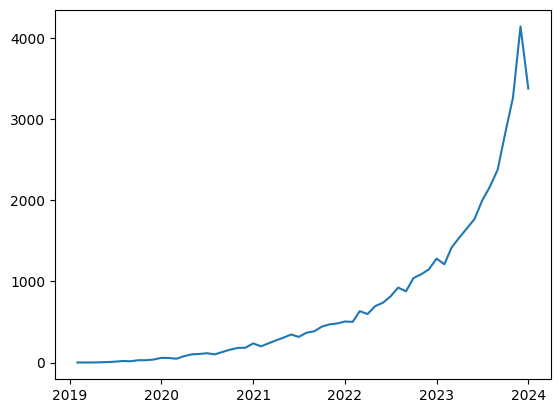

In [10]:
plt.plot(result.index, result['n_orders'])

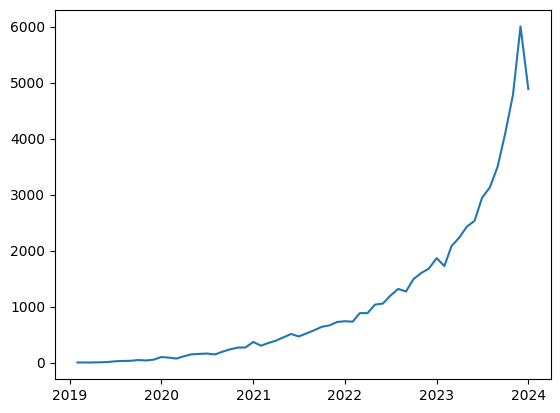

In [11]:
plt.plot(result.index, result['n_items'])

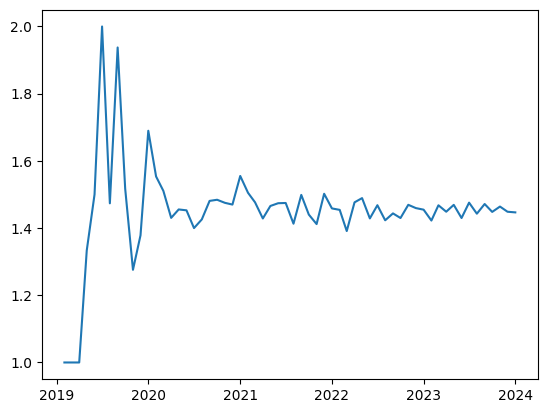

In [12]:
plt.plot(result.index, result['n_items'] / result['n_orders'])

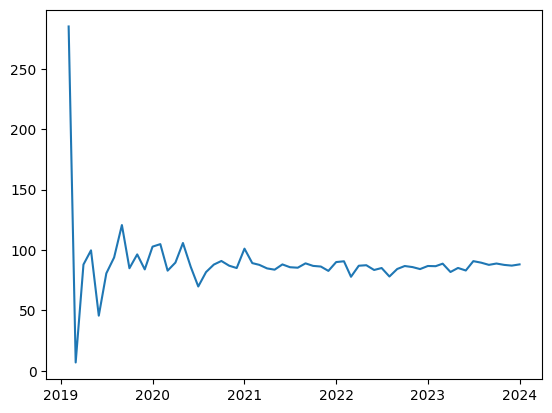

In [13]:
plt.plot(result.index, result['tot_rev'] / result['n_orders'])

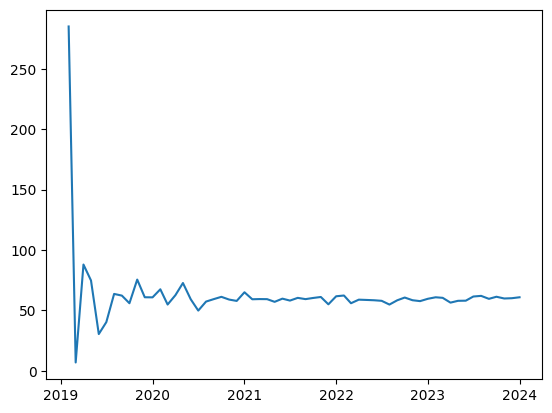

In [14]:
plt.plot(result.index, result['tot_rev'] / result['n_items'])

In [15]:
# now I want to break this apart by other values

In [16]:
dim_result = repeated_order_itms.groupby(['month', 'traffic_source', 'age_bin', 'gender_x', 'country'], observed=True).agg(
    n_orders=('order_id', 'nunique'),
    n_items=('id_y', 'count'),
    tot_rev=('sale_price', 'sum')
).reset_index()
dim_result

,month,traffic_source,age_bin,gender_x,country,n_orders,n_items,tot_rev
0,2019-02-01,Search,"[20, 30)",F,China,1,1,285.00
1,2019-03-01,Display,"[20, 30)",F,China,1,1,6.95
2,2019-04-01,Search,"[30, 40)",F,France,1,1,88.00
3,2019-05-01,Facebook,"[50, 60)",M,South Korea,1,1,36.00
4,2019-05-01,Search,"[10, 20)",M,Japan,1,2,193.24
...,...,...,...,...,...,...,...,...
10740,2024-01-01,Search,"[60, 70)",M,Poland,1,1,34.65
10741,2024-01-01,Search,"[60, 70)",M,South Korea,11,15,1289.53
10742,2024-01-01,Search,"[60, 70)",M,Spain,8,12,712.32
10743,2024-01-01,Search,"[60, 70)",M,United Kingdom,9,11,1282.98


In [17]:
age_dim_result = dim_result.groupby(['month', 'age_bin'], observed=True).agg(
    n_orders=('n_orders', 'sum'),
    n_items=('n_items', 'sum'),
    tot_rev=('tot_rev', 'sum')
).reset_index()

In [18]:
age_dim_result

,month,age_bin,n_orders,n_items,tot_rev
0,2019-02-01,"[20, 30)",1,1,285.00
1,2019-03-01,"[20, 30)",1,1,6.95
2,2019-04-01,"[30, 40)",1,1,88.00
3,2019-05-01,"[10, 20)",1,2,193.24
4,2019-05-01,"[50, 60)",2,2,105.99
...,...,...,...,...,...
332,2024-01-01,"[20, 30)",646,913,56241.96
333,2024-01-01,"[30, 40)",511,733,45966.86
334,2024-01-01,"[40, 50)",584,855,52378.44
335,2024-01-01,"[50, 60)",566,838,50435.79


In [19]:
age_dim_result['avg_items_per_order'] = age_dim_result['n_items'] / age_dim_result['n_orders']
age_dim_result['avg_order_rev'] = age_dim_result['tot_rev'] / age_dim_result['n_orders']
age_dim_result['avg_item_rev'] = age_dim_result['tot_rev'] / age_dim_result['n_items']

In [20]:
age_dim_result

,month,age_bin,n_orders,n_items,tot_rev,avg_items_per_order,avg_order_rev,avg_item_rev
0,2019-02-01,"[20, 30)",1,1,285.00,1.000000,285.000000,285.000000
1,2019-03-01,"[20, 30)",1,1,6.95,1.000000,6.950000,6.950000
2,2019-04-01,"[30, 40)",1,1,88.00,1.000000,88.000000,88.000000
3,2019-05-01,"[10, 20)",1,2,193.24,2.000000,193.240000,96.620000
4,2019-05-01,"[50, 60)",2,2,105.99,1.000000,52.995000,52.995000
...,...,...,...,...,...,...,...,...
332,2024-01-01,"[20, 30)",646,913,56241.96,1.413313,87.061858,61.601271
333,2024-01-01,"[30, 40)",511,733,45966.86,1.434442,89.954716,62.710587
334,2024-01-01,"[40, 50)",584,855,52378.44,1.464041,89.689110,61.261333
335,2024-01-01,"[50, 60)",566,838,50435.79,1.480565,89.109170,60.185907


<Axes: xlabel='month', ylabel='n_orders'>

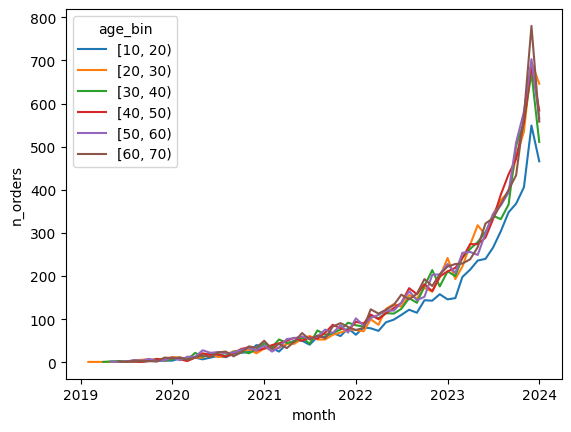

In [21]:
sns.lineplot(data=age_dim_result, x='month', y='n_orders', hue='age_bin')

<Axes: xlabel='month', ylabel='n_items'>

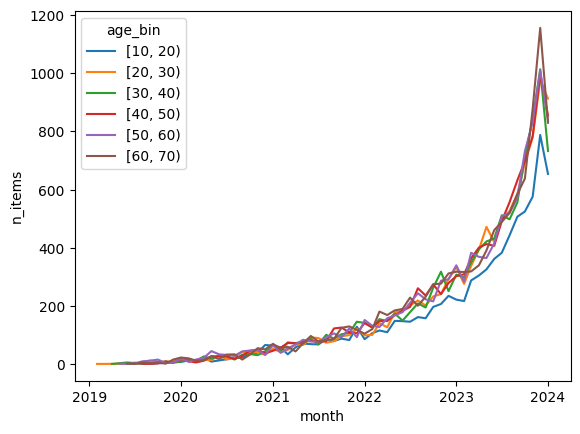

In [22]:
sns.lineplot(data=age_dim_result, x='month', y='n_items', hue='age_bin')

<Axes: xlabel='month', ylabel='avg_items_per_order'>

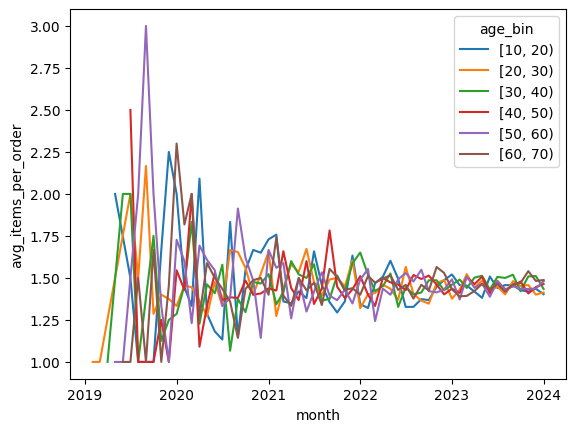

In [23]:
sns.lineplot(data=age_dim_result, x='month', y='avg_items_per_order', hue='age_bin')

<Axes: xlabel='month', ylabel='avg_order_rev'>

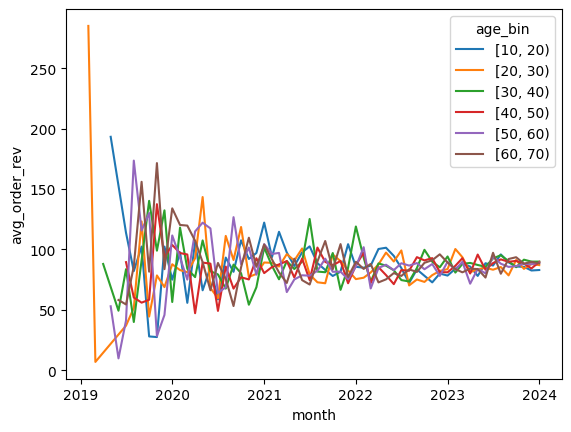

In [24]:
sns.lineplot(data=age_dim_result, x='month', y='avg_order_rev', hue='age_bin')

<Axes: xlabel='month', ylabel='avg_item_rev'>

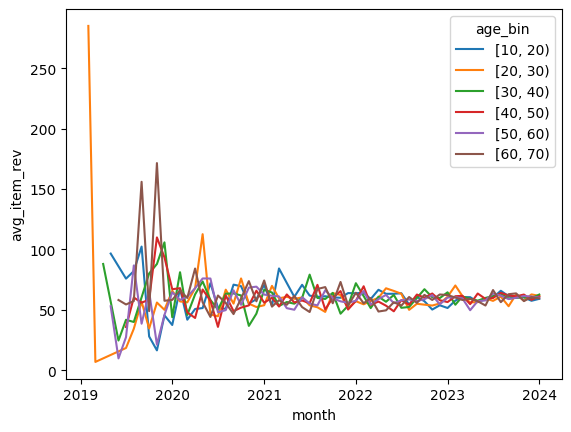

In [25]:
sns.lineplot(data=age_dim_result, x='month', y='avg_item_rev', hue='age_bin')

In [26]:
channel_dim_result = dim_result.groupby(['month', 'traffic_source'], observed=True).agg(
    n_orders=('n_orders', 'sum'),
    n_items=('n_items', 'sum'),
    tot_rev=('tot_rev', 'sum')
).reset_index()

channel_dim_result['avg_items_per_order'] = channel_dim_result['n_items'] / channel_dim_result['n_orders']
channel_dim_result['avg_order_rev'] = channel_dim_result['tot_rev'] / channel_dim_result['n_orders']
channel_dim_result['avg_item_rev'] = channel_dim_result['tot_rev'] / channel_dim_result['n_items']

In [27]:
channel_dim_result

,month,traffic_source,n_orders,n_items,tot_rev,avg_items_per_order,avg_order_rev,avg_item_rev
0,2019-02-01,Search,1,1,285.00,1.000000,285.000000,285.000000
1,2019-03-01,Display,1,1,6.95,1.000000,6.950000,6.950000
2,2019-04-01,Search,1,1,88.00,1.000000,88.000000,88.000000
3,2019-05-01,Facebook,1,1,36.00,1.000000,36.000000,36.000000
4,2019-05-01,Search,2,3,263.23,1.500000,131.615000,87.743333
...,...,...,...,...,...,...,...,...
268,2024-01-01,Display,139,191,11713.85,1.374101,84.272302,61.329058
269,2024-01-01,Email,175,253,15440.84,1.445714,88.233371,61.030988
270,2024-01-01,Facebook,193,276,17960.66,1.430052,93.060415,65.074855
271,2024-01-01,Organic,514,730,42254.67,1.420233,82.207529,57.883110


<Axes: xlabel='month', ylabel='n_orders'>

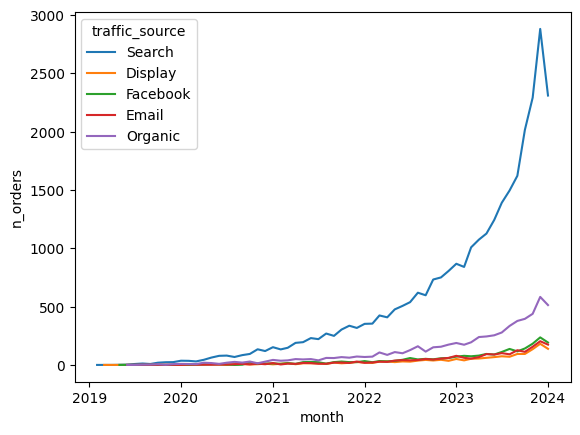

In [28]:
sns.lineplot(data=channel_dim_result, x='month', y='n_orders', hue='traffic_source')

<Axes: xlabel='month', ylabel='n_items'>

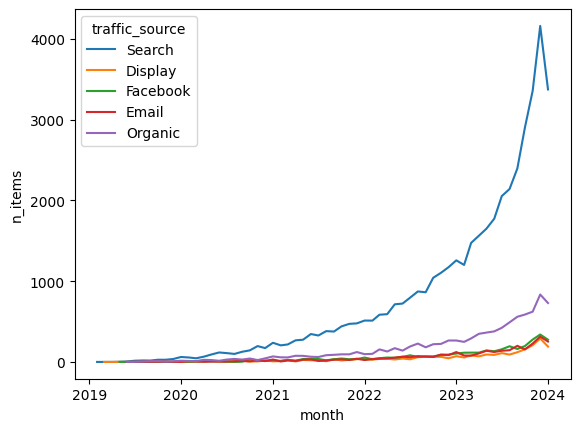

In [29]:
sns.lineplot(data=channel_dim_result, x='month', y='n_items', hue='traffic_source')

<Axes: xlabel='month', ylabel='avg_items_per_order'>

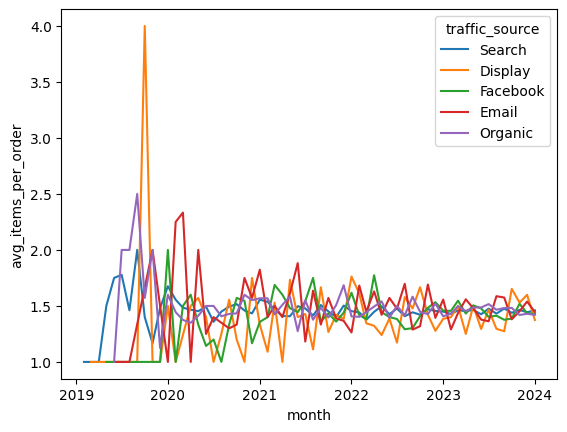

In [30]:
sns.lineplot(data=channel_dim_result, x='month', y='avg_items_per_order', hue='traffic_source')

<Axes: xlabel='month', ylabel='avg_order_rev'>

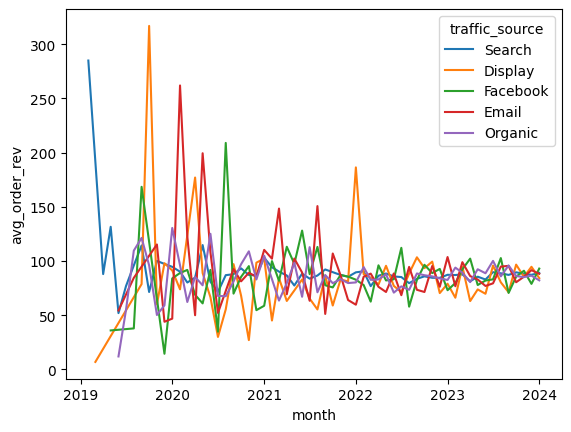

In [31]:
sns.lineplot(data=channel_dim_result, x='month', y='avg_order_rev', hue='traffic_source')

<Axes: xlabel='month', ylabel='avg_item_rev'>

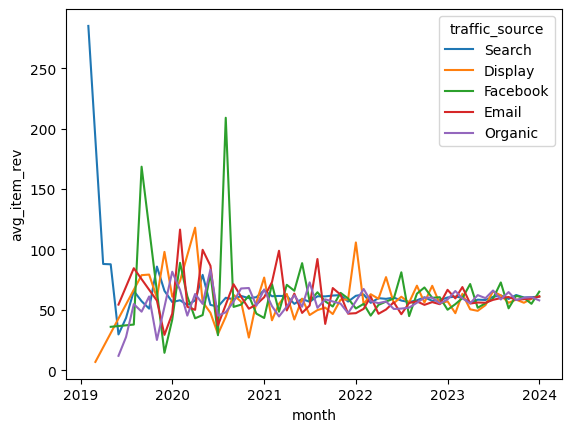

In [32]:
sns.lineplot(data=channel_dim_result, x='month', y='avg_item_rev', hue='traffic_source')

In [33]:
gender_dim_result = dim_result.groupby(['month', 'gender_x'], observed=True).agg(
    n_orders=('n_orders', 'sum'),
    n_items=('n_items', 'sum'),
    tot_rev=('tot_rev', 'sum')
).reset_index()

gender_dim_result['avg_items_per_order'] = gender_dim_result['n_items'] / gender_dim_result['n_orders']
gender_dim_result['avg_order_rev'] = gender_dim_result['tot_rev'] / gender_dim_result['n_orders']
gender_dim_result['avg_item_rev'] = gender_dim_result['tot_rev'] / gender_dim_result['n_items']

In [34]:
gender_dim_result

,month,gender_x,n_orders,n_items,tot_rev,avg_items_per_order,avg_order_rev,avg_item_rev
0,2019-02-01,F,1,1,285.00,1.000000,285.000000,285.000000
1,2019-03-01,F,1,1,6.95,1.000000,6.950000,6.950000
2,2019-04-01,F,1,1,88.00,1.000000,88.000000,88.000000
3,2019-05-01,F,1,1,69.99,1.000000,69.990000,69.990000
4,2019-05-01,M,2,3,229.24,1.500000,114.620000,76.413333
...,...,...,...,...,...,...,...,...
112,2023-11-01,M,1605,2358,147409.42,1.469159,91.843875,62.514597
113,2023-12-01,F,2028,2946,165648.16,1.452663,81.680552,56.228160
114,2023-12-01,M,2060,2993,191127.36,1.452913,92.780272,63.858122
115,2024-01-01,F,1693,2442,137367.19,1.442410,81.138328,56.251921


<Axes: xlabel='month', ylabel='n_orders'>

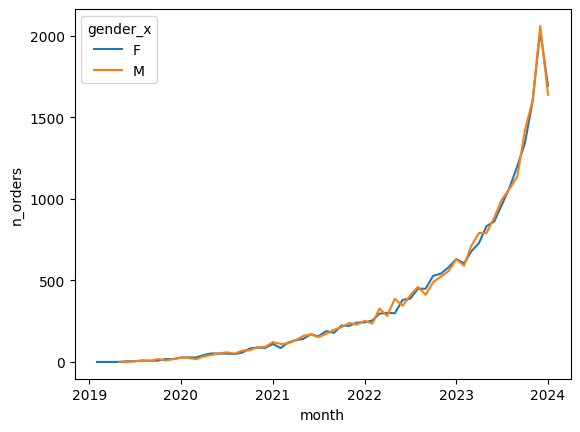

In [35]:
sns.lineplot(data=gender_dim_result, x='month', y='n_orders', hue='gender_x')

<Axes: xlabel='month', ylabel='n_items'>

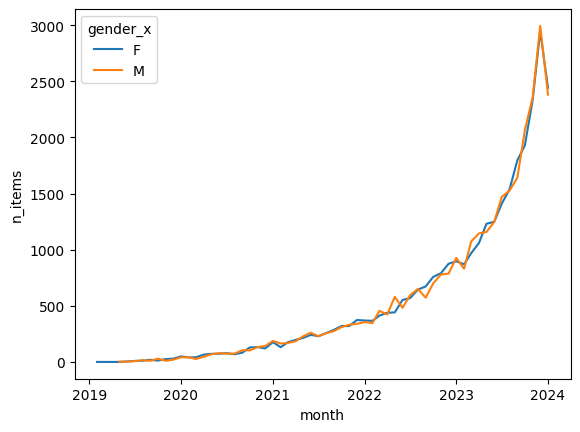

In [36]:
sns.lineplot(data=gender_dim_result, x='month', y='n_items', hue='gender_x')

<Axes: xlabel='month', ylabel='avg_items_per_order'>

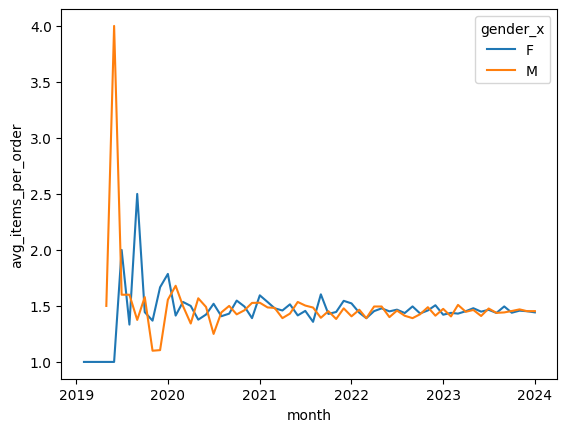

In [37]:
sns.lineplot(data=gender_dim_result, x='month', y='avg_items_per_order', hue='gender_x')

<Axes: xlabel='month', ylabel='avg_order_rev'>

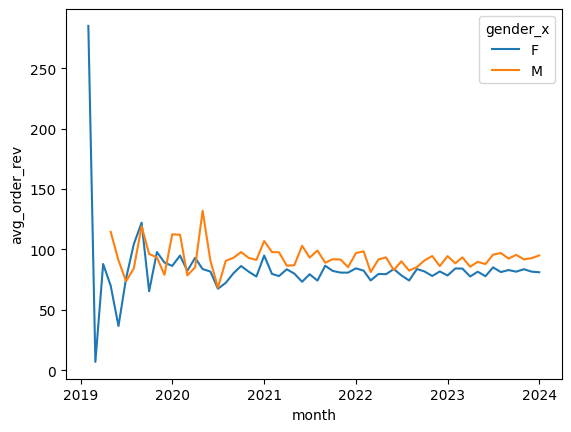

In [38]:
sns.lineplot(data=gender_dim_result, x='month', y='avg_order_rev', hue='gender_x')

<Axes: xlabel='month', ylabel='avg_item_rev'>

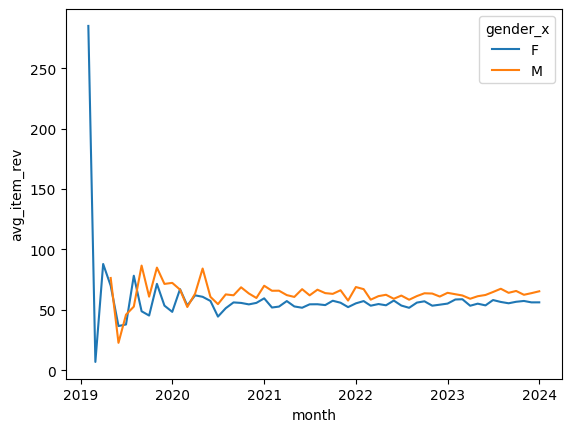

In [39]:
sns.lineplot(data=gender_dim_result, x='month', y='avg_item_rev', hue='gender_x')

In [40]:
country_dim_result = dim_result.groupby(['month', 'country'], observed=True).agg(
    n_orders=('n_orders', 'sum'),
    n_items=('n_items', 'sum'),
    tot_rev=('tot_rev', 'sum')
).reset_index()

country_dim_result['avg_items_per_order'] = country_dim_result['n_items'] / country_dim_result['n_orders']
country_dim_result['avg_order_rev'] = country_dim_result['tot_rev'] / country_dim_result['n_orders']
country_dim_result['avg_item_rev'] = country_dim_result['tot_rev'] / country_dim_result['n_items']

In [41]:
country_dim_result

,month,country,n_orders,n_items,tot_rev,avg_items_per_order,avg_order_rev,avg_item_rev
0,2019-02-01,China,1,1,285.00,1.000000,285.000000,285.000000
1,2019-03-01,China,1,1,6.95,1.000000,6.950000,6.950000
2,2019-04-01,France,1,1,88.00,1.000000,88.000000,88.000000
3,2019-05-01,China,1,1,69.99,1.000000,69.990000,69.990000
4,2019-05-01,Japan,1,2,193.24,2.000000,193.240000,96.620000
...,...,...,...,...,...,...,...,...
619,2024-01-01,Poland,12,16,872.67,1.333333,72.722500,54.541875
620,2024-01-01,South Korea,175,248,17235.95,1.417143,98.491143,69.499798
621,2024-01-01,Spain,130,183,9611.33,1.407692,73.933308,52.520929
622,2024-01-01,United Kingdom,163,235,13380.85,1.441718,82.091104,56.939787


<Axes: xlabel='month', ylabel='n_orders'>

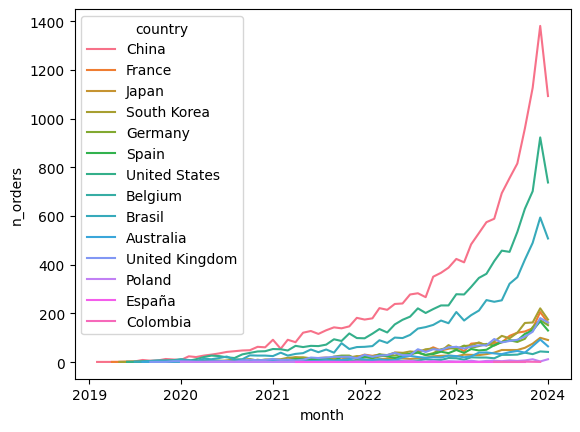

In [42]:
sns.lineplot(data=country_dim_result, x='month', y='n_orders', hue='country')

<Axes: xlabel='month', ylabel='n_items'>

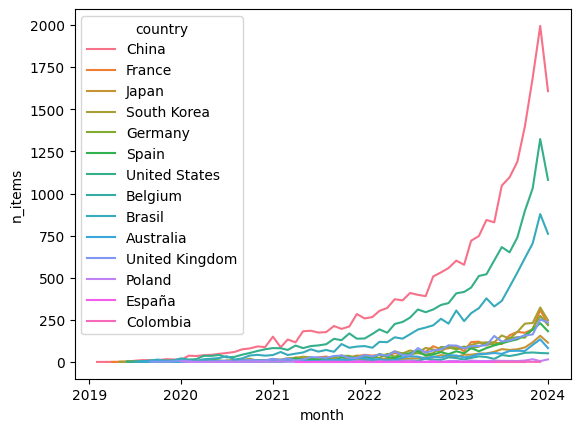

In [43]:
sns.lineplot(data=country_dim_result, x='month', y='n_items', hue='country')

<Axes: xlabel='month', ylabel='avg_items_per_order'>

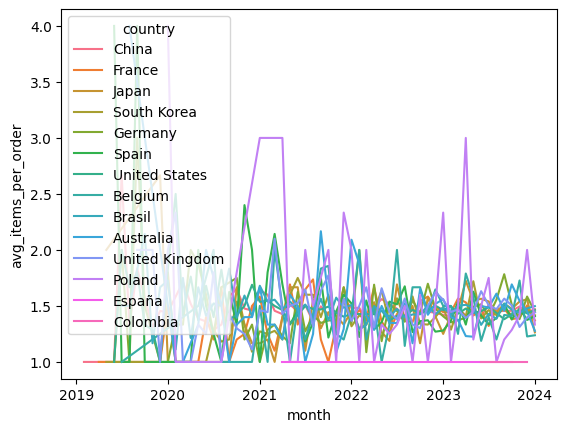

In [44]:
sns.lineplot(data=country_dim_result, x='month', y='avg_items_per_order', hue='country')

<Axes: xlabel='month', ylabel='avg_order_rev'>

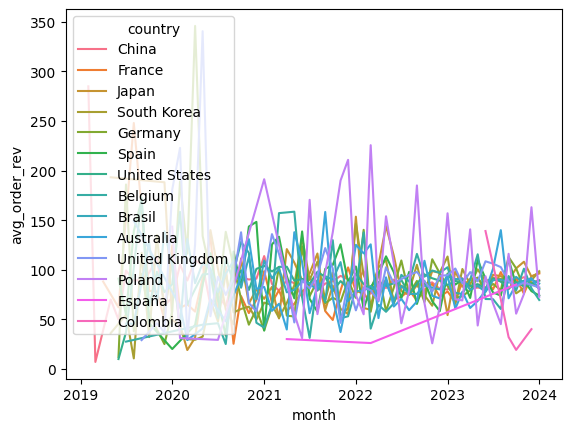

In [45]:
sns.lineplot(data=country_dim_result, x='month', y='avg_order_rev', hue='country')

<Axes: xlabel='month', ylabel='avg_item_rev'>

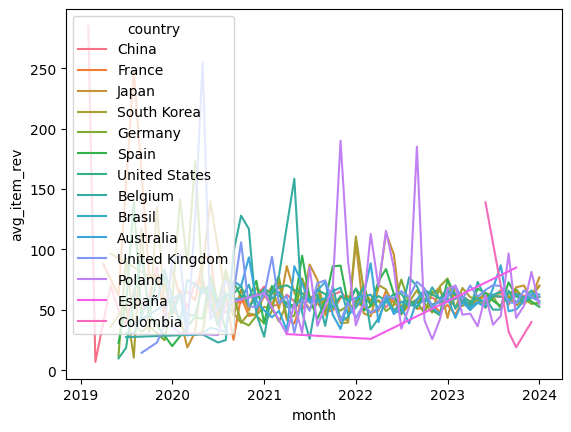

In [46]:
sns.lineplot(data=country_dim_result, x='month', y='avg_item_rev', hue='country')

### Which customer behaviours best predict long-term value (e.g. first-purchase category, AOV, time to second order), where long-term value is defined by revenue, profit, and repeat purchases?
Metrics of interest: Long term value
- Total revenue
- Total Profit
- Repeat purchases
Dimensions of interest
- Acquisition channel
- Gender
- Country
- Age
- average order value
Other behaviours
- Average order value (bins)
- timet to second order (bins)
- first purchase category (bins)
    - Department
    - Category
    - Total order price

Actions
for each person add values according to their
- Total revenue
- Total profit
- Repeat purchases (orders)

Include
- Acquisition channel
- Gender
- Country
- Age + age bin
- Average order value + bin
- Time to second purchase + bin
- Most common category
- Most common department
- First order total revenue + bin


In [47]:
# first orders, then order items, then products

In [48]:
user_order_itms = users.merge(orders, left_on='id', right_on='user_id').merge(order_items, on='order_id').merge(products, left_on='product_id', right_on='id')
user_order_itms['month'] = user_order_itms['created_at_y'].dt.to_period('M')
user_order_itms['month'] = user_order_itms['month'].dt.to_timestamp()
user_order_itms['age_bin'] = pd.cut(
    user_order_itms['age'],
    bins=range(10, 81, 10),
    right=False
)
user_order_itms

,id_x,first_name,last_name,email,age,gender_x,state,street_address,postal_code,city,...,cost,category,name,brand,retail_price,department,sku,distribution_center_id,month,age_bin
0,457,Timothy,Bush,timothybush@example.net,65,M,Acre,87620 Johnson Hills,69917-400,Rio Branco,...,39.70,Suits & Sport Coats,Haggar Men's Shadow Stripe 2-Button Center Ven...,Haggar,99.99,Men,8671E7B4D35F3D498F22E225DBE70BD9,6,2023-10-01,"[60, 70)"
1,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,...,12.17,Suits & Sport Coats,Allegra K Men Worsted Long Sleeve Padded Shoul...,Allegra K,29.97,Men,8EB42DB3C9772AF6DBA6F1B9F7095FEB,9,2020-05-01,"[10, 20)"
2,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,...,8.79,Sleep & Lounge,Private Label - Mens Plaid Broadcloth Robe Bla...,Private Label,23.12,Men,5F7733DE9C8BDDEB31B24D3434640003,3,2021-01-01,"[10, 20)"
3,36280,Christopher,Mendoza,christophermendoza@example.net,13,M,Acre,125 Turner Isle Apt. 264,69917-400,Rio Branco,...,24.01,Shorts,Hurley Men's Sinatra Walkshort,Hurley,49.00,Men,A797A65AA8651D8B93208615C6E0D01F,1,2021-01-01,"[10, 20)"
4,60193,Jimmy,Conner,jimmyconner@example.com,64,M,Acre,0966 Jose Branch Apt. 008,69917-400,Rio Branco,...,15.31,Socks,Smartwool NEW Men's PhD Running Light Micro wi...,SmartWool,24.00,Men,A6B25CC04DE4031B55EF0AEF421EC4A4,2,2021-03-01,"[60, 70)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181754,57045,Olivia,Wiley,oliviawiley@example.org,53,F,Île-de-France,749 Ronald Forge,77320,Choisy-en-Brie,...,22.68,Active,Moving Comfort Women's Juno Bra,Moving Comfort,56.00,Women,3430095C577593AAD3C39C701712BCFE,3,2021-09-01,"[50, 60)"
181755,73312,Emily,Bird,emilybird@example.org,16,F,Île-de-France,78117 Anderson Oval,77320,Choisy-en-Brie,...,5.06,Intimates,Vanity Fair Women's Smooth Moves Brief Panty #...,Vanity Fair,9.50,Women,63E8E3643E7F7198858EEF325B0600F9,2,2023-08-01,"[10, 20)"
181756,73312,Emily,Bird,emilybird@example.org,16,F,Île-de-France,78117 Anderson Oval,77320,Choisy-en-Brie,...,35.12,Fashion Hoodies & Sweatshirts,Coolibar UPF 50+ Women's ZnO Cabana Hoodie - S...,Coolibar,69.00,Women,3A1DD98341FAFC1DFE9BCF36360E6B84,5,2023-08-01,"[10, 20)"
181757,77764,Deborah,Andrews,deborahandrews@example.com,67,F,Île-de-France,922 Jeffrey Station,77320,Choisy-en-Brie,...,87.55,Jeans,7 For All Mankind Women's Midrise Bootcut Jean,7 For All Mankind,170.99,Women,038D5463327ADDF90D282C35BE4C5EB1,8,2023-08-01,"[60, 70)"


In [49]:
user_value = user_order_itms.groupby(['id_x', 'traffic_source', 'age', 'age_bin', 'gender_x', 'country'], observed=True).agg(
    tot_rev=('sale_price', 'sum'),
    tot_cost=('cost', 'sum'),
    n_ords=('order_id', 'nunique')
).reset_index()
user_value['aov'] = user_value['tot_rev'] / user_value['n_ords']
user_value['tot_profit'] = user_value['tot_rev'] - user_value['tot_cost']
user_value['aop'] = user_value['tot_profit'] / user_value['n_ords']
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840
...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970


In [50]:
# time to second purchase
# first sort by id_x and created_at
user_order_itms = user_order_itms.sort_values(['id_x', 'created_at_y'])

In [51]:
# group by
order_orders = user_order_itms.groupby(['id_x', 'order_id'], as_index=False).agg(
    created=('created_at_y', 'min')
)
order_orders = order_orders.sort_values(['id_x', 'created'])
order_orders['order_n'] = order_orders.groupby('id_x').cumcount()
order_orders

,id_x,order_id,created,order_n
0,1,1,2022-07-18 12:55:00,0
1,2,2,2022-02-20 10:34:00,0
4,3,5,2023-03-10 09:13:00,0
5,3,6,2023-04-02 09:13:00,1
2,3,3,2023-04-23 09:13:00,2
...,...,...,...,...
125221,99998,125222,2023-01-28 07:27:00,1
125222,99998,125223,2023-07-22 07:27:00,2
125223,99999,125224,2023-12-22 11:29:00,0
125225,100000,125226,2020-08-29 03:04:00,0


In [52]:
second_order_gap = order_orders.query('order_n in [0, 1]').pivot(index='id_x', columns='order_n', values='created')
second_order_gap

order_n,0,1
id_x,,
1,2022-07-18 12:55:00,NaT
2,2022-02-20 10:34:00,NaT
3,2023-03-10 09:13:00,2023-04-02 09:13:00
4,2022-10-18 09:31:00,NaT
5,2022-10-20 10:03:00,NaT
...,...,...
99993,2024-01-03 03:09:00,NaT
99996,2020-08-02 02:00:00,2023-03-13 02:00:00
99998,2022-12-16 07:27:00,2023-01-28 07:27:00


In [53]:
second_order_gap['time_to_second_order (days)'] = (
    second_order_gap[1] - second_order_gap[0]
).dt.days
second_order_gap = second_order_gap.reset_index()
second_order_gap
second_order_gap

order_n,id_x,0,1,time_to_second_order (days)
0,1,2022-07-18 12:55:00,NaT,NaN
1,2,2022-02-20 10:34:00,NaT,NaN
2,3,2023-03-10 09:13:00,2023-04-02 09:13:00,23.0
3,4,2022-10-18 09:31:00,NaT,NaN
4,5,2022-10-20 10:03:00,NaT,NaN
...,...,...,...,...
80039,99993,2024-01-03 03:09:00,NaT,NaN
80040,99996,2020-08-02 02:00:00,2023-03-13 02:00:00,953.0
80041,99998,2022-12-16 07:27:00,2023-01-28 07:27:00,43.0
80042,99999,2023-12-22 11:29:00,NaT,NaN


In [54]:
user_value = user_value.merge(second_order_gap.reset_index()[['id_x', 'time_to_second_order (days)']], on='id_x')
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop,time_to_second_order (days)
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860,NaN
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620,NaN
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335,23.0
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430,NaN
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450,NaN
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090,953.0
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090,43.0
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970,NaN


In [55]:
first_order = order_orders[order_orders['order_n'] == 0]
first_order.merge(order_items, on='order_id')

,id_x,order_id,created,order_n,id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,1,1,2022-07-18 12:55:00,0,1,1,2953,3,Shipped,2022-07-20 10:32:05,2022-07-20 16:42:00,NaT,NaT,15.00
1,1,1,2022-07-18 12:55:00,0,3,1,7656,9,Shipped,2022-07-19 11:29:28,2022-07-20 16:42:00,NaT,NaT,19.99
2,1,1,2022-07-18 12:55:00,0,2,1,4731,7,Shipped,2022-07-20 11:05:38,2022-07-20 16:42:00,NaT,NaT,125.00
3,2,2,2022-02-20 10:34:00,0,4,2,25774,11,Complete,2022-02-20 10:28:57,2022-02-22 12:23:00,2022-02-23 18:29:00,NaT,22.00
4,3,5,2023-03-10 09:13:00,0,7,3,18177,18,Shipped,2023-03-10 07:14:45,2023-03-11 12:33:00,NaT,NaT,109.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116107,99996,125219,2020-08-02 02:00:00,0,181749,99996,27368,490678,Processing,2020-08-01 23:33:20,NaT,NaT,NaT,40.00
116108,99998,125221,2022-12-16 07:27:00,0,181753,99998,19164,490690,Processing,2022-12-16 06:35:21,NaT,NaT,NaT,40.00
116109,99999,125224,2023-12-22 11:29:00,0,181756,99999,25959,490697,Shipped,2023-12-23 08:59:09,2023-12-24 00:44:00,NaT,NaT,25.00
116110,99999,125224,2023-12-22 11:29:00,0,181757,99999,20828,490700,Shipped,2023-12-23 11:33:17,2023-12-24 00:44:00,NaT,NaT,42.98


In [56]:
first_order = order_orders[order_orders['order_n'] == 0]
first_order_rev = first_order.merge(order_items, on='order_id').groupby('id_x').agg(
    first_order_rev = ('sale_price', 'sum')
).reset_index()
first_order_rev

,id_x,first_order_rev
0,1,159.99
1,2,22.00
2,3,109.99
3,4,148.00
4,5,65.65
...,...,...
80039,99993,26.00
80040,99996,61.00
80041,99998,40.00
80042,99999,67.98


In [57]:
user_value = user_value.merge(first_order_rev, on='id_x')

In [58]:
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop,time_to_second_order (days),first_order_rev
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860,NaN,159.99
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620,NaN,22.00
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335,23.0,109.99
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430,NaN,148.00
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840,NaN,65.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450,NaN,26.00
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090,953.0,61.00
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090,43.0,40.00
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970,NaN,67.98


In [59]:
# now most common category
# we break ties by revenue
most_common_cat = user_order_itms.groupby(['id_x', 'category']).agg(
    n_items=('id_y', 'count'),
    cost=('cost', 'sum')
).reset_index()
most_common_cat = most_common_cat.sort_values(['id_x', 'n_items', 'cost'], ascending=False)
most_common_cat['category_pop'] = most_common_cat.groupby('id_x').cumcount()
most_common_cat = most_common_cat[most_common_cat['category_pop'] == 0][['id_x', 'category']]

user_value = user_value.merge(most_common_cat, on='id_x', how='left')
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop,time_to_second_order (days),first_order_rev,category
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860,NaN,159.99,Jeans
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620,NaN,22.00,Underwear
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335,23.0,109.99,Active
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430,NaN,148.00,Sweaters
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840,NaN,65.65,Sweaters
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450,NaN,26.00,Sleep & Lounge
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090,953.0,61.00,Socks
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090,43.0,40.00,Tops & Tees
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970,NaN,67.98,Jeans


In [60]:
# now most common department
# we break ties by revenue
most_common_dep = user_order_itms.groupby(['id_x', 'department']).agg(
    n_items=('id_y', 'count'),
    cost=('cost', 'sum')
).reset_index()


most_common_dep = most_common_dep.sort_values(['id_x', 'n_items', 'cost'], ascending=False)
most_common_dep['dep_pop'] = most_common_dep.groupby('id_x').cumcount()
most_common_dep = most_common_dep[most_common_dep['dep_pop'] == 0][['id_x', 'department']]

user_value = user_value.merge(most_common_dep, on='id_x')
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop,time_to_second_order (days),first_order_rev,category,department
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860,NaN,159.99,Jeans,Women
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620,NaN,22.00,Underwear,Men
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335,23.0,109.99,Active,Men
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430,NaN,148.00,Sweaters,Women
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840,NaN,65.65,Sweaters,Women
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450,NaN,26.00,Sleep & Lounge,Women
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090,953.0,61.00,Socks,Men
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090,43.0,40.00,Tops & Tees,Men
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970,NaN,67.98,Jeans,Men


In [ ]:
user_order_itms['age_bin'] = pd.cut(
    user_order_itms['age'],
    bins=range(10, 81, 10),
    right=False
)

In [111]:
(user_value['first_order_rev'].min(),
 user_value['first_order_rev'].max())

(np.float64(0.49), np.float64(1341.49))

In [112]:
# finally bin behaviours into categories
user_value['ttso_bin'] = pd.cut(
    user_value['time_to_second_order (days)'],
    bins=range(0, 1750, 250),
    right=False
)
user_value['first_order_rev_bin'] = pd.cut(
    user_value['first_order_rev'],
    bins=range(0, 1500, 250),
    right=False
)

## Visualisations

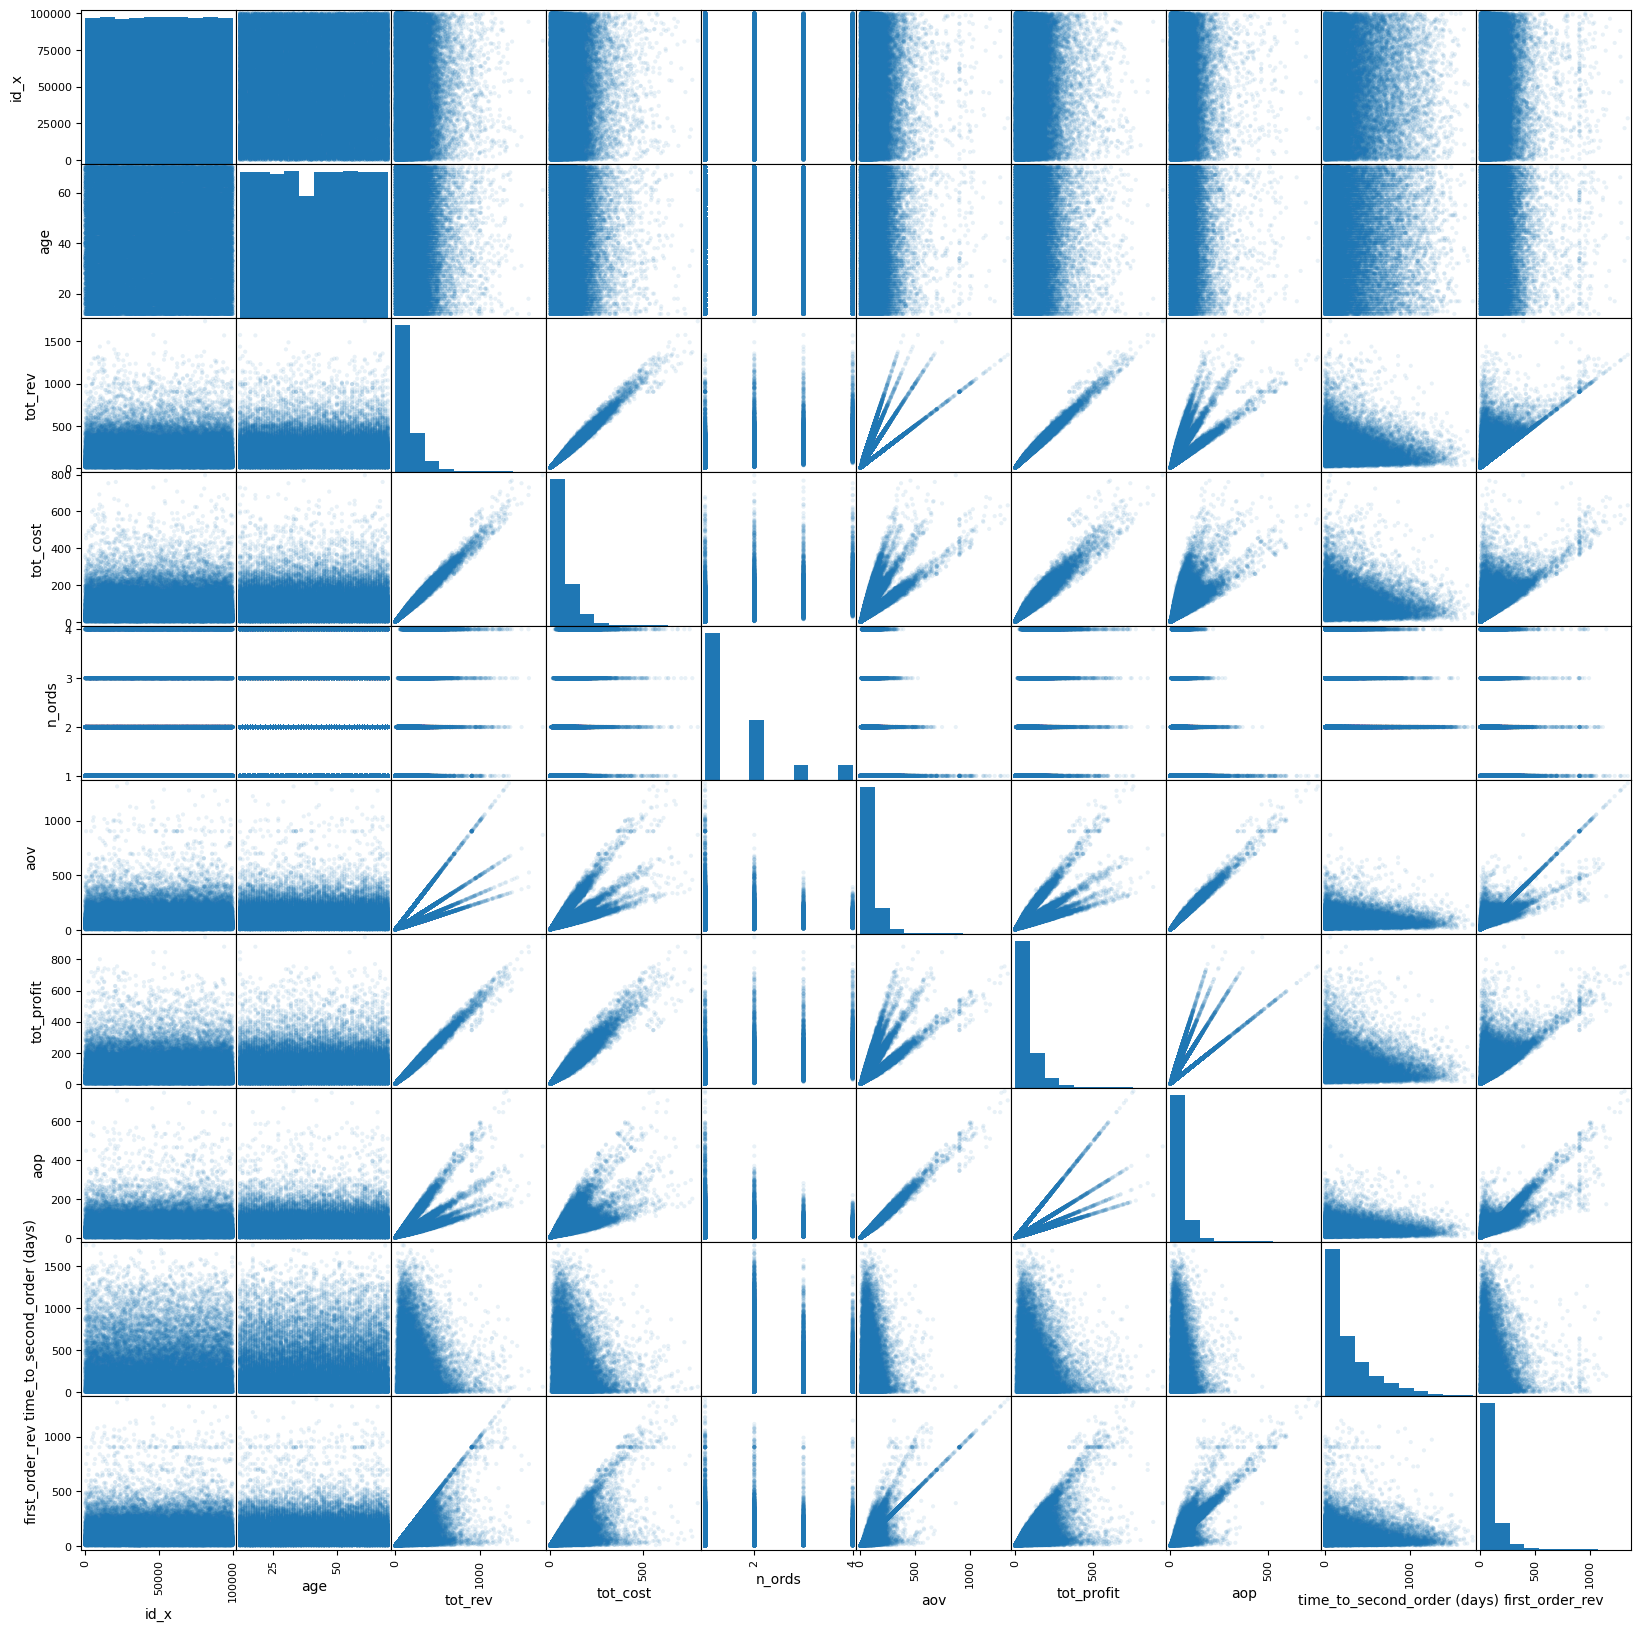

In [62]:
pd.plotting.scatter_matrix(user_value, alpha=0.1, diagonal='hist', figsize=(20, 20))
plt.show()

In [63]:
user_value

,id_x,traffic_source,age,age_bin,gender_x,country,tot_rev,tot_cost,n_ords,aov,tot_profit,aop,time_to_second_order (days),first_order_rev,category,department
0,1,Search,62,"[60, 70)",F,South Korea,159.99,81.13,1,159.990000,78.86,78.860,NaN,159.99,Jeans,Women
1,2,Organic,65,"[60, 70)",M,Brasil,22.00,10.38,1,22.000000,11.62,11.620,NaN,22.00,Underwear,Men
2,3,Organic,16,"[10, 20)",M,United States,402.20,196.86,4,100.550000,205.34,51.335,23.0,109.99,Active,Men
3,4,Search,12,"[10, 20)",F,United States,148.00,61.57,1,148.000000,86.43,86.430,NaN,148.00,Sweaters,Women
4,5,Organic,52,"[50, 60)",F,Brasil,65.65,28.81,1,65.650000,36.84,36.840,NaN,65.65,Sweaters,Women
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80039,99993,Search,17,"[10, 20)",F,Australia,26.00,15.55,1,26.000000,10.45,10.450,NaN,26.00,Sleep & Lounge,Women
80040,99996,Search,51,"[50, 60)",M,China,123.87,55.69,2,61.935000,68.18,34.090,953.0,61.00,Socks,Men
80041,99998,Search,51,"[50, 60)",M,United States,116.99,59.72,3,38.996667,57.27,19.090,43.0,40.00,Tops & Tees,Men
80042,99999,Search,13,"[10, 20)",M,Brasil,67.98,34.01,1,67.980000,33.97,33.970,NaN,67.98,Jeans,Men


Metrics of interest: Long term value
- Total revenue
- Total Profit
- aov
- aop
User characteristics
- Age
- Gender
- Country
User behaviours
- Acquisition channel
- time to second order
- first order revenue
- most common category
- most common department

In [113]:
ltv = ['tot_rev', 'tot_profit', 'aov', 'aop']
c = ['age', 'gender_x', 'country']
b = ['n_ords', 'time_to_second_order (days)', 'ttso_bin', 'first_order_rev', 'first_order_rev_bin', 'traffic_source', 'category', 'department']

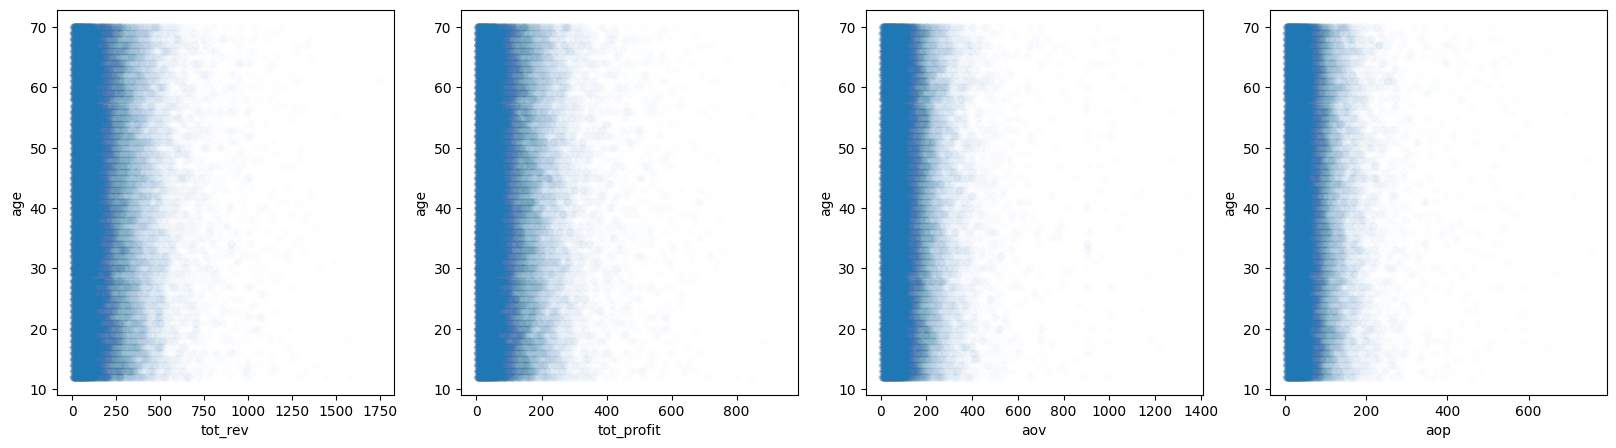

In [90]:
fig, ax = plt.subplots(1, len(ltv), figsize = (20, 5))
v = c[0]
for i in range(len(ltv)):
    sns.scatterplot(data=user_value, x=ltv[i], y = v, ax=ax[i], alpha=0.01)
plt.show()

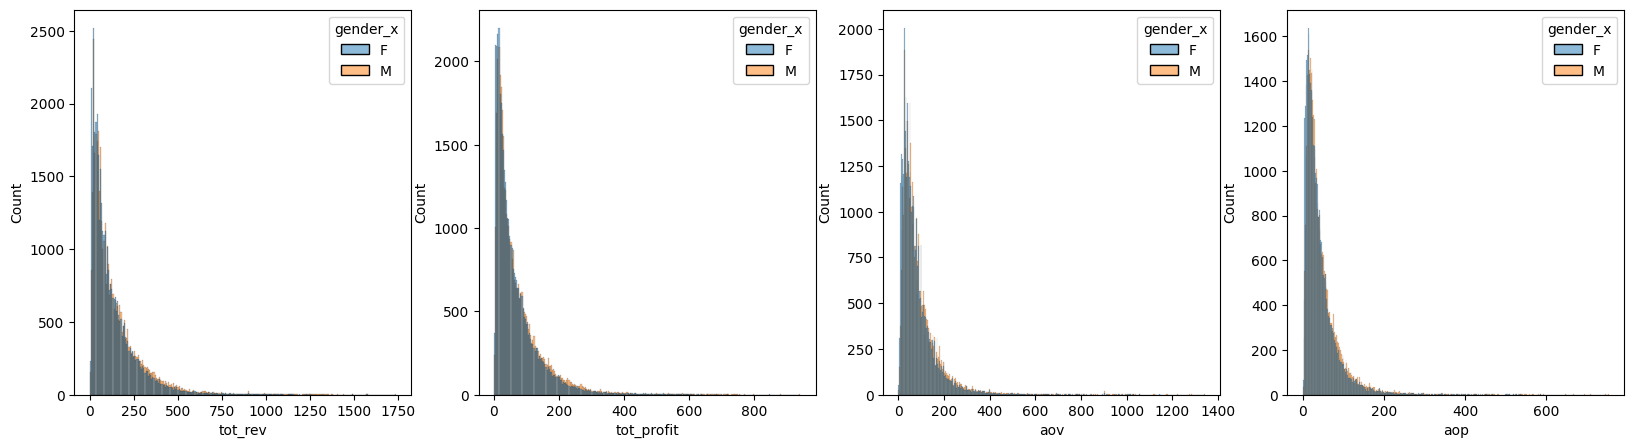

In [91]:
fig, ax = plt.subplots(1, len(ltv), figsize = (20, 5))
v = c[1]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

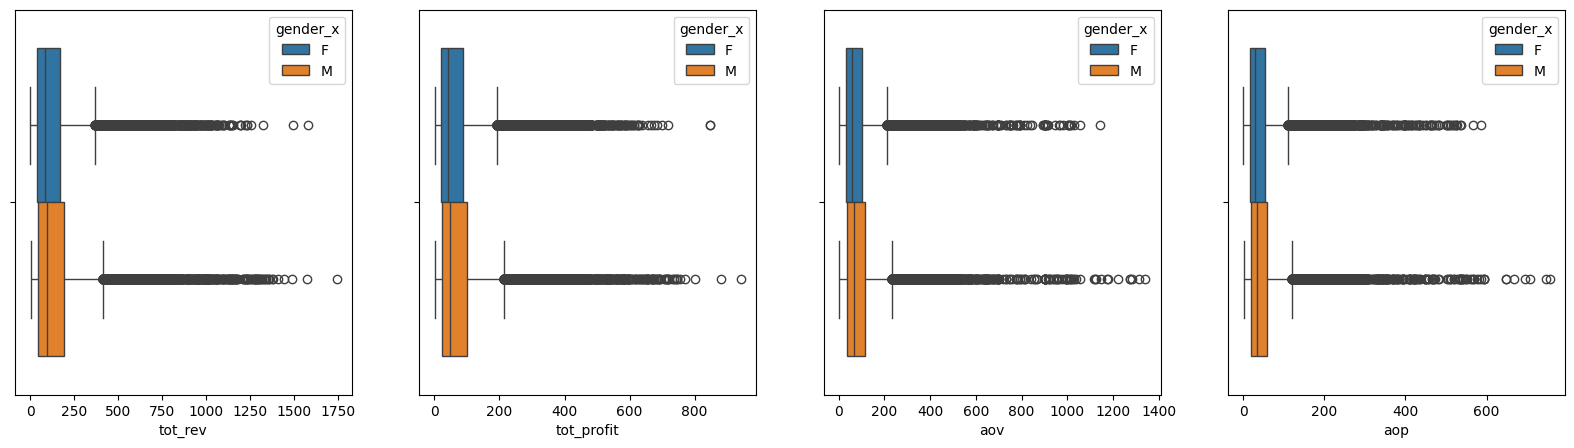

In [125]:
fig, ax = plt.subplots(1, len(ltv), figsize = (20, 5))
v = c[1]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

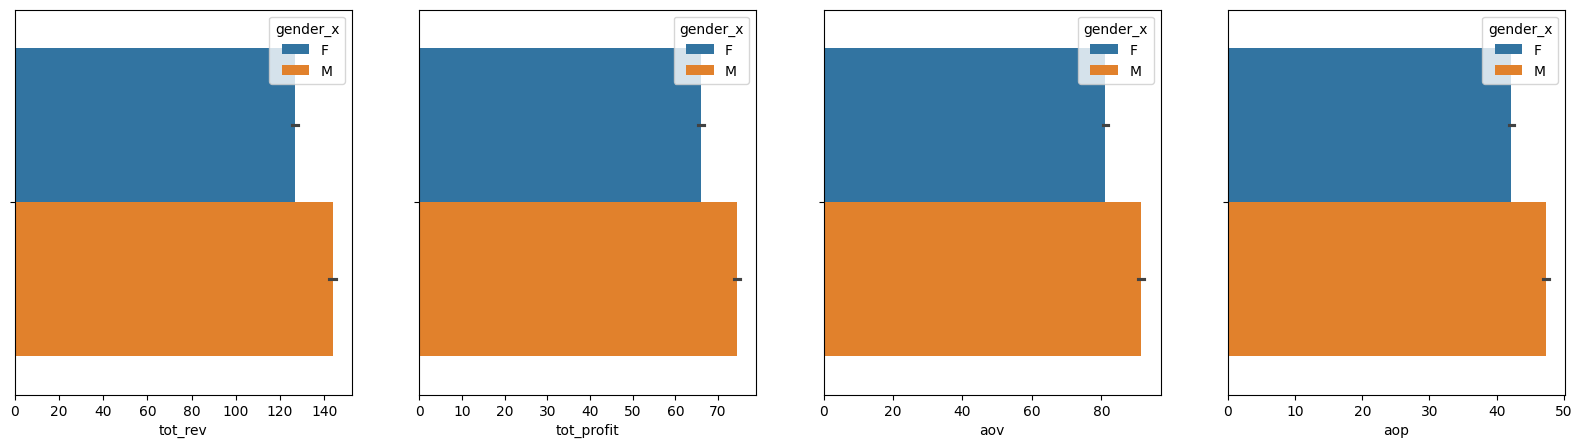

In [126]:
fig, ax = plt.subplots(1, len(ltv), figsize = (20, 5))
v = c[1]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

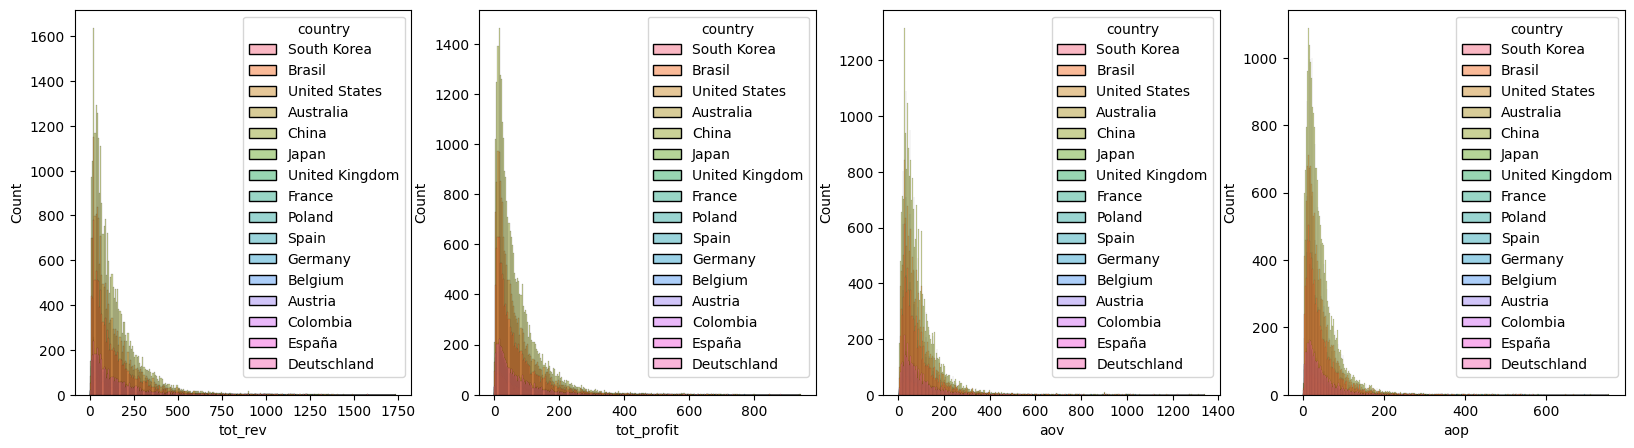

In [92]:
fig, ax = plt.subplots(1, len(ltv), figsize = (20, 5))
v = c[2]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

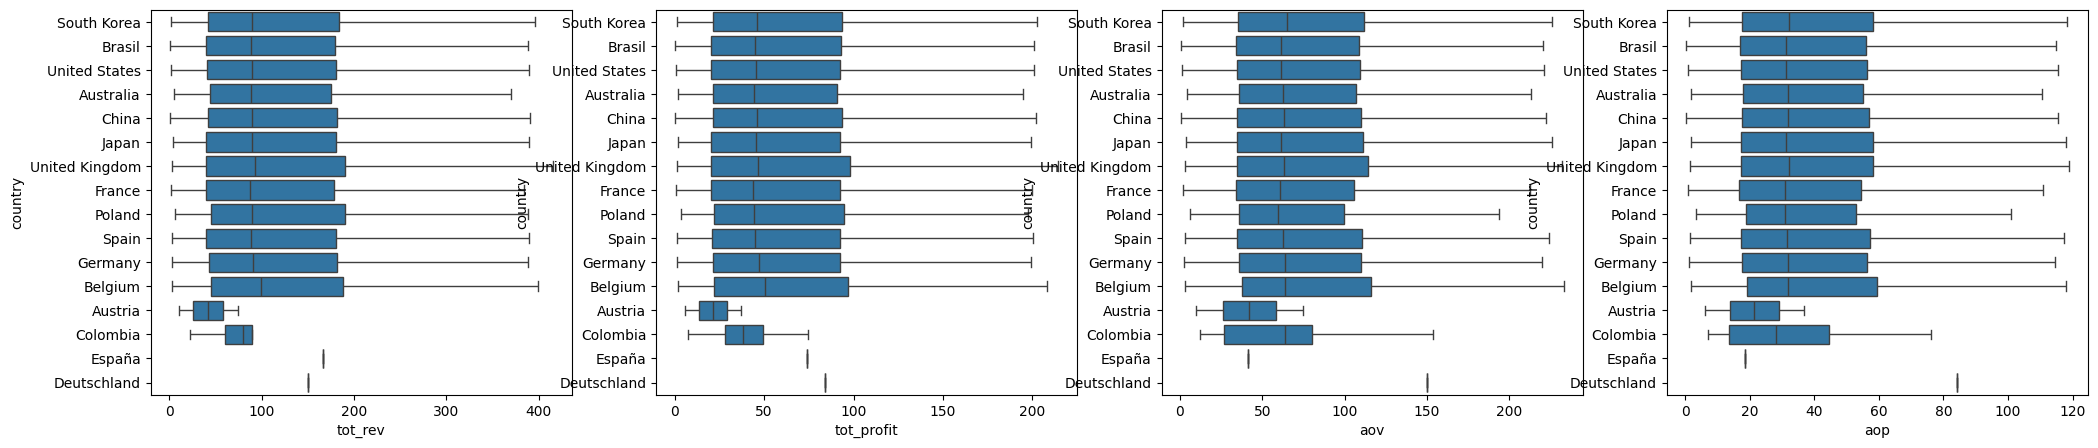

In [93]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = c[2]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], y = v, ax=ax[i], showfliers=False)
plt.show()

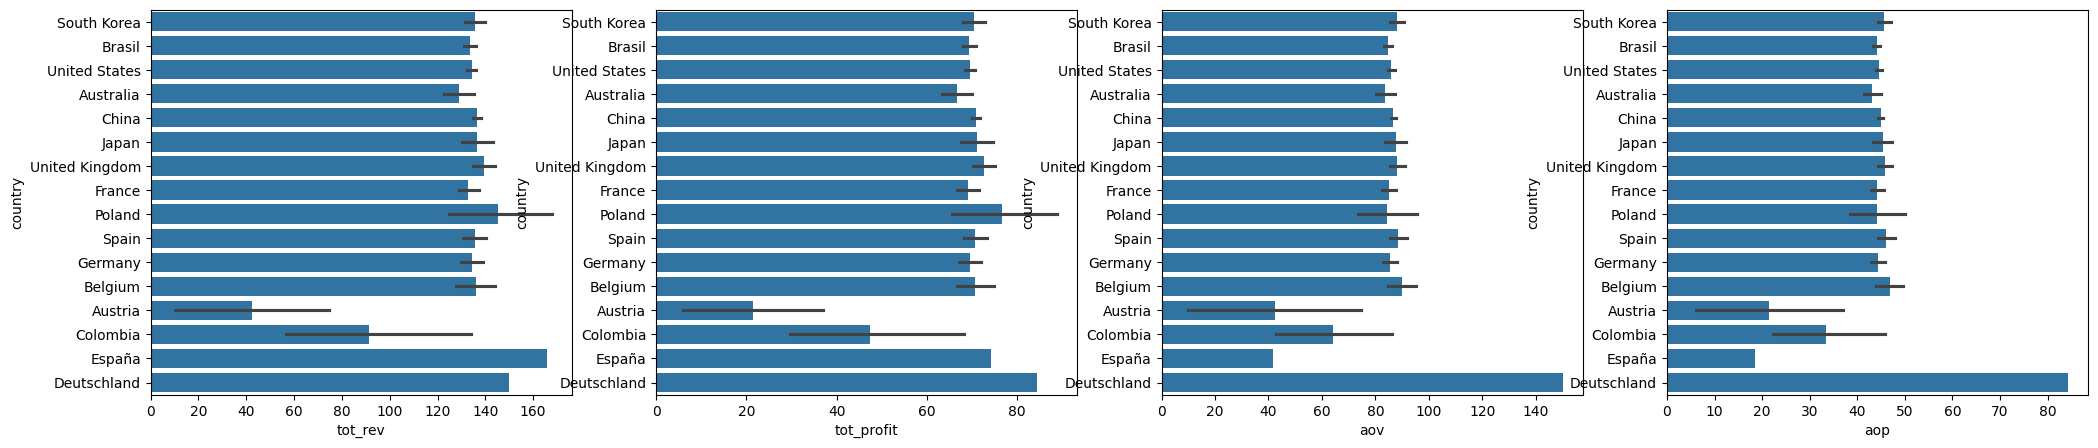

In [94]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = c[2]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], y = v, ax=ax[i])
plt.show()

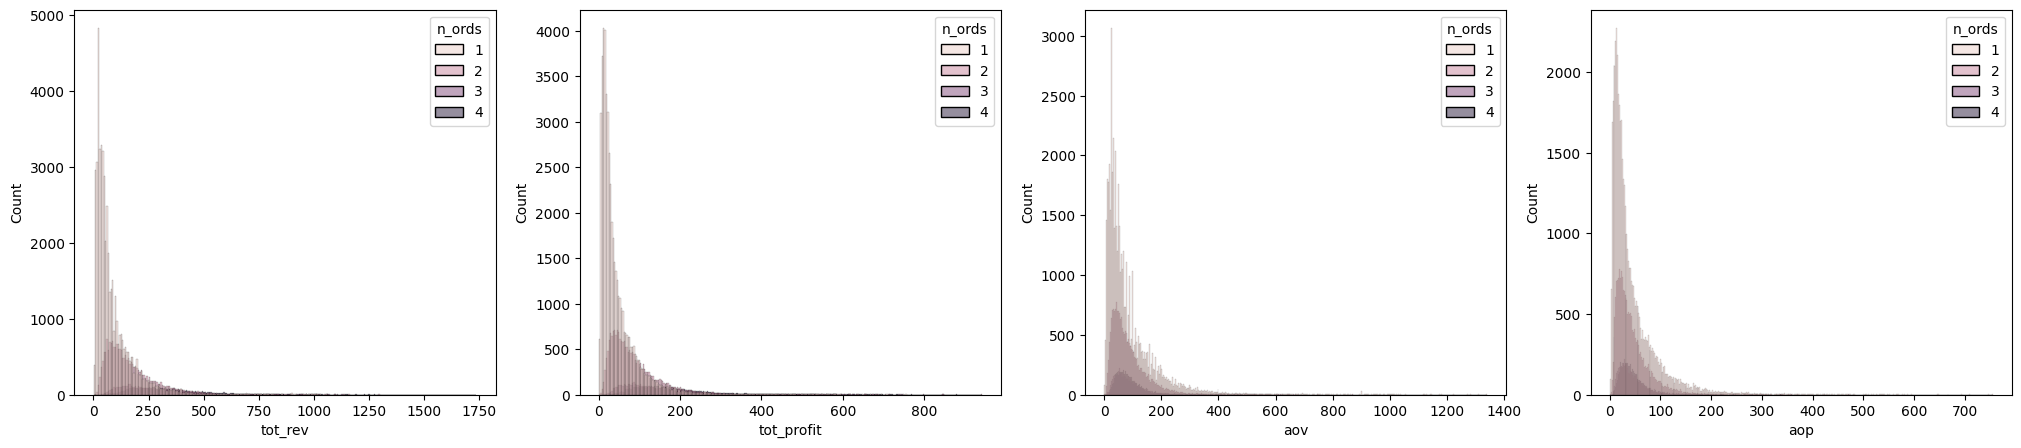

In [95]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[0]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

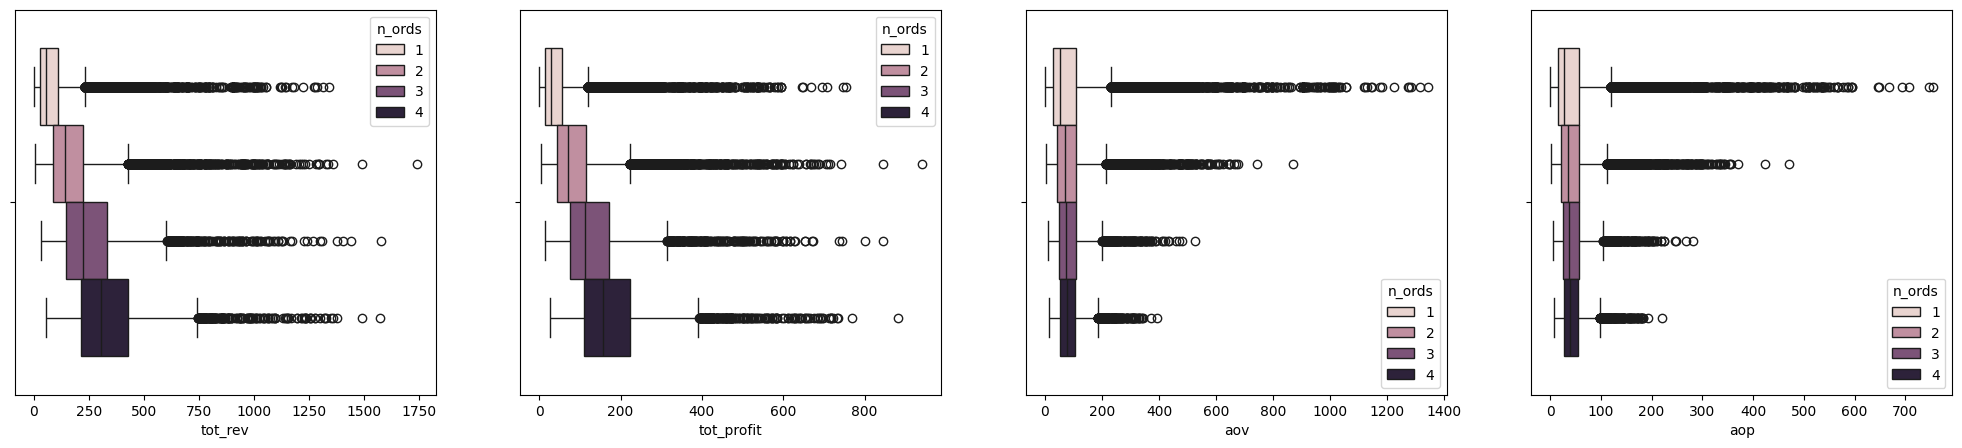

In [96]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[0]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

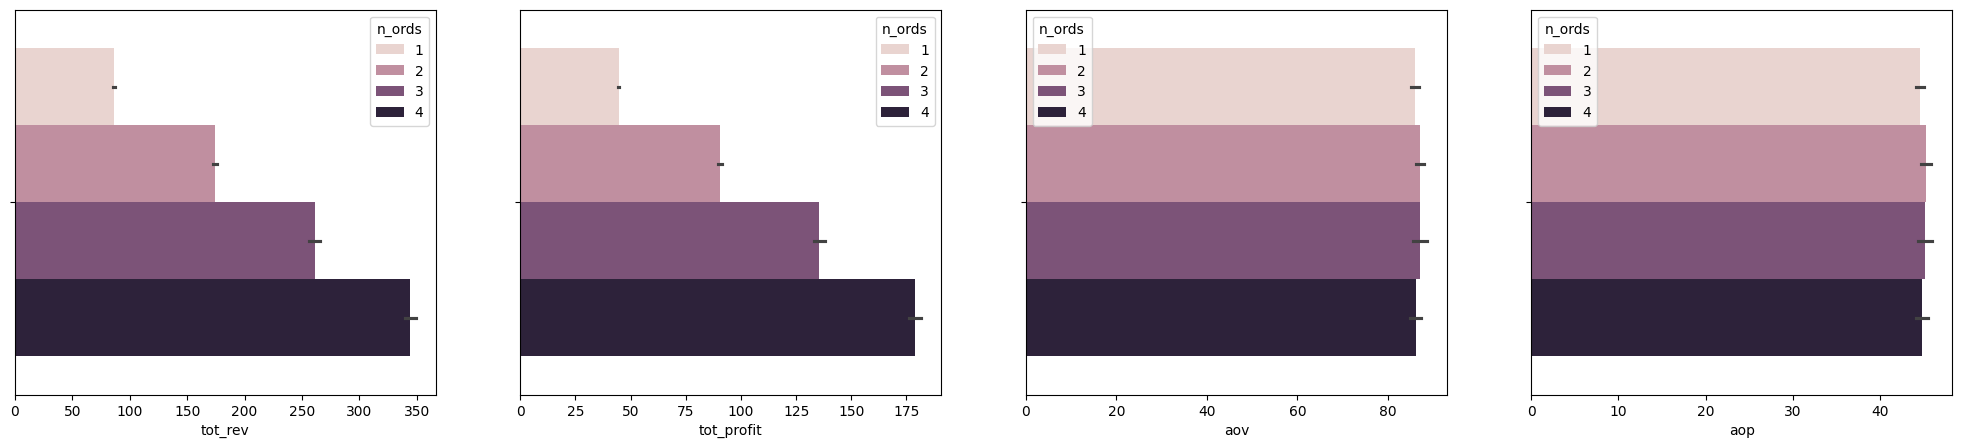

In [97]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[0]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

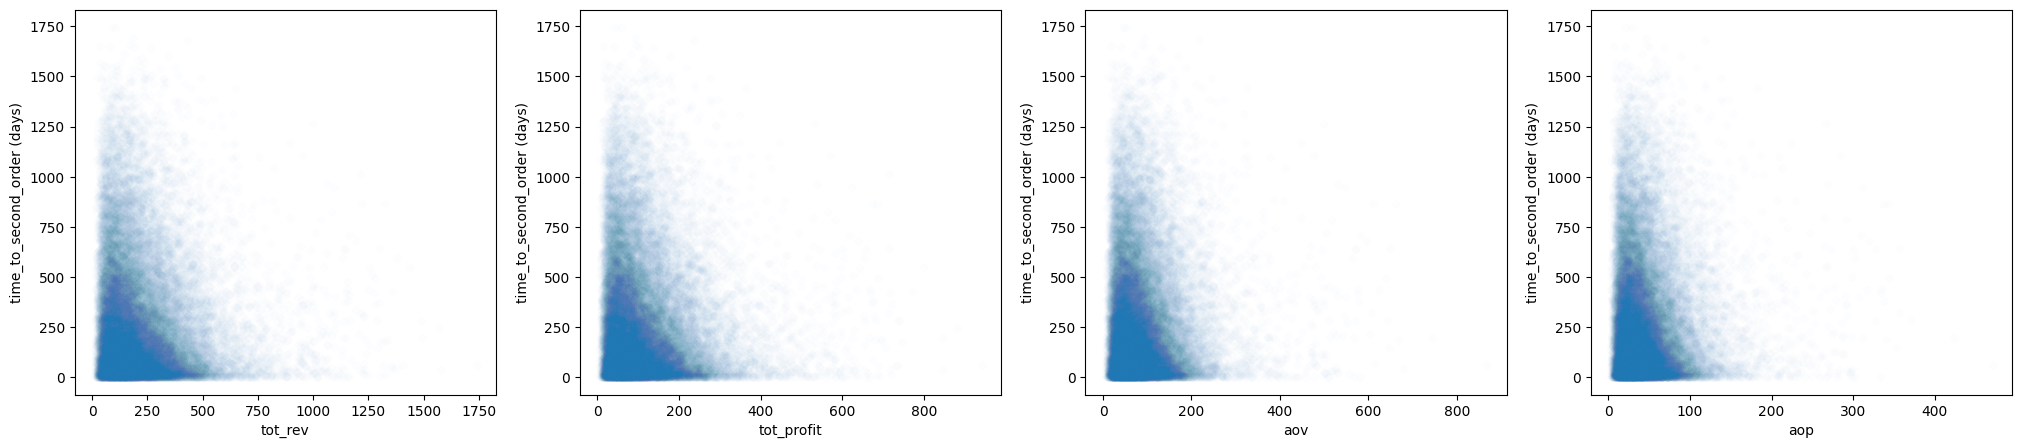

In [98]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[1]
for i in range(len(ltv)):
    sns.scatterplot(data=user_value, x=ltv[i], y = v, ax=ax[i], alpha=0.01)
plt.show()

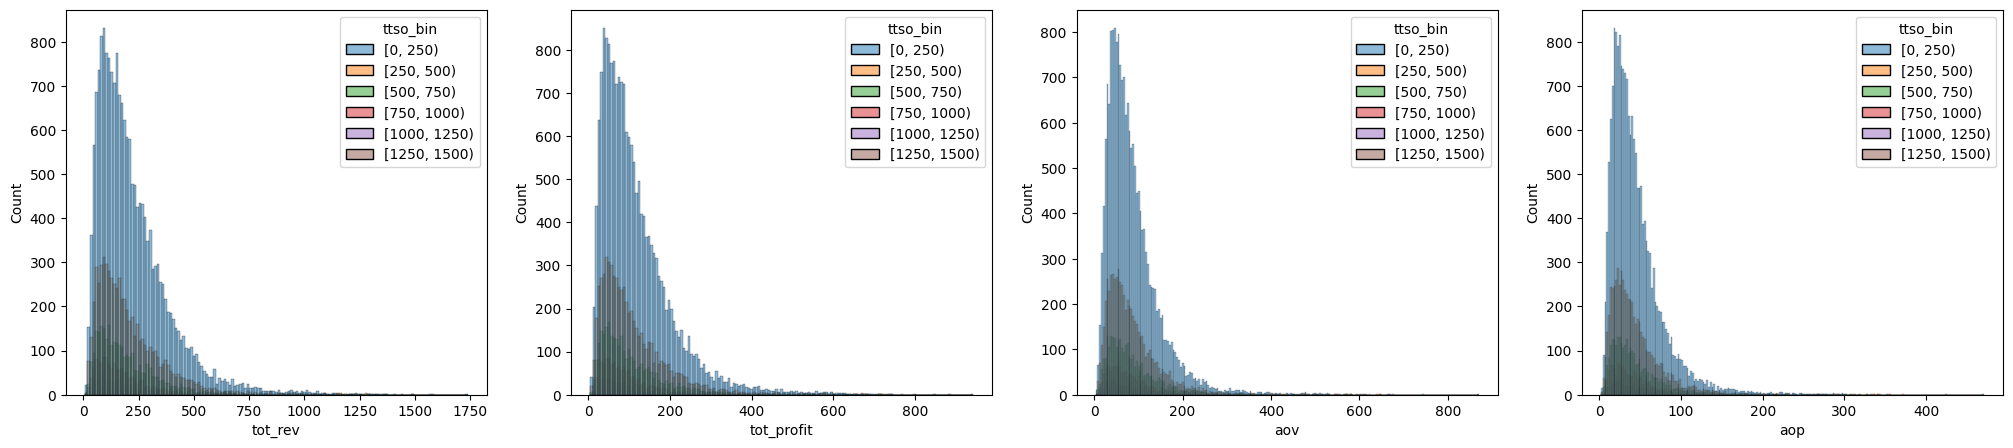

In [99]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[2]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

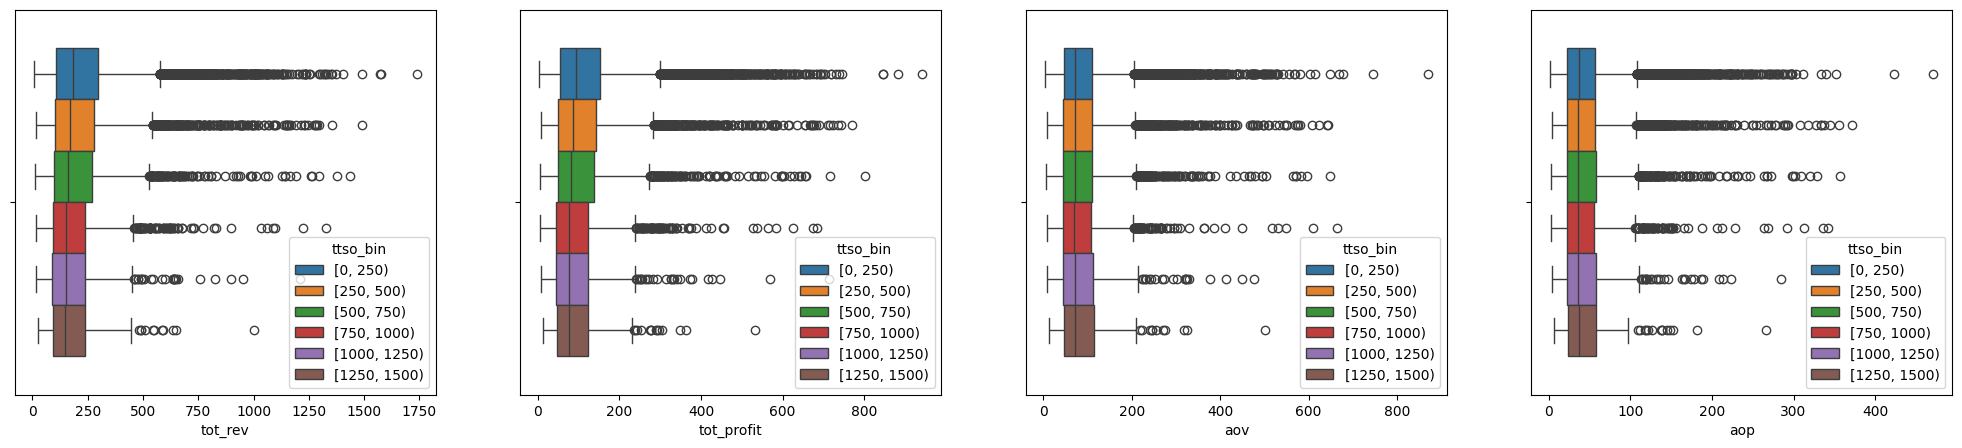

In [100]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[2]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

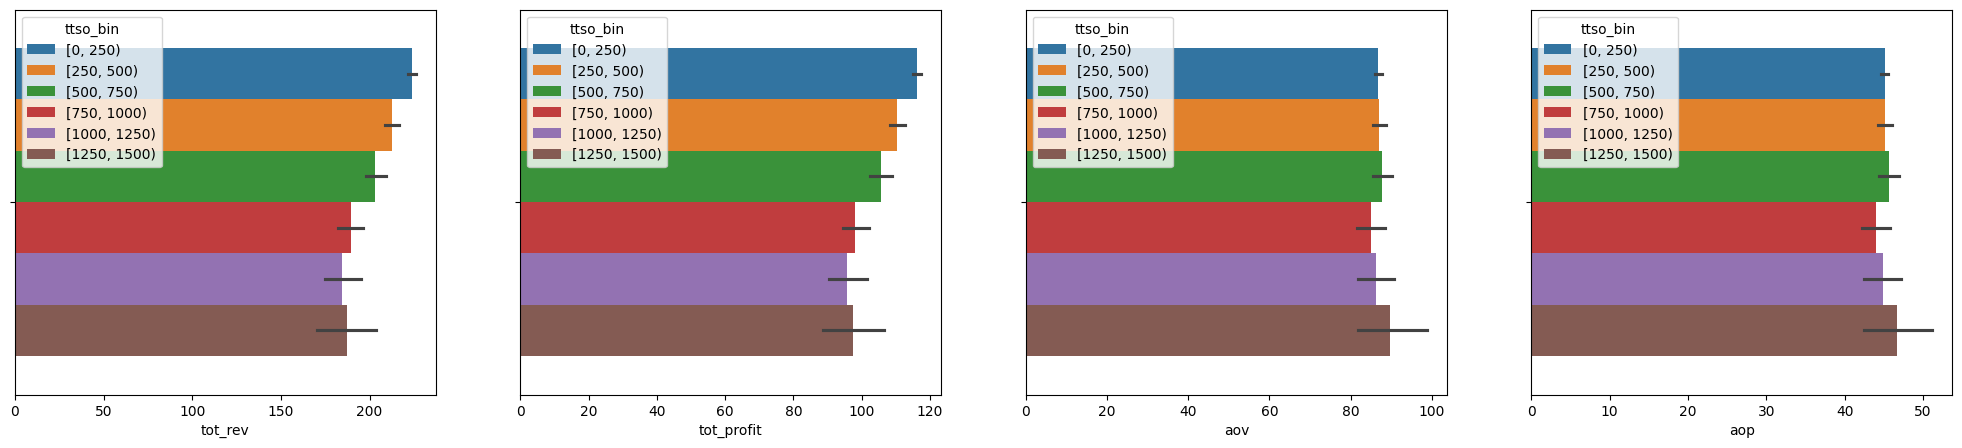

In [101]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[2]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

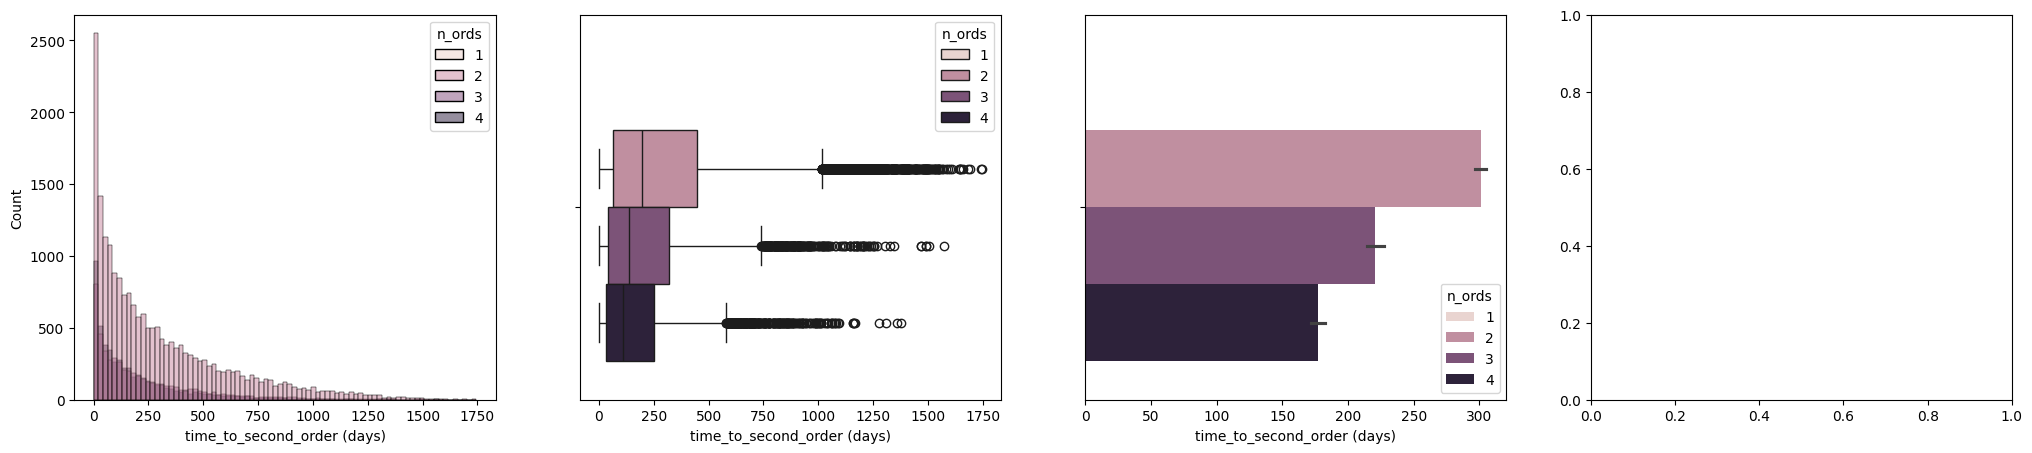

In [106]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[2]
sns.histplot(data=user_value, x='time_to_second_order (days)', hue = 'n_ords', ax=ax[0])
sns.boxplot(data=user_value, x='time_to_second_order (days)', hue = 'n_ords', ax=ax[1])
sns.barplot(data=user_value, x='time_to_second_order (days)', hue = 'n_ords', ax=ax[2])
plt.show()

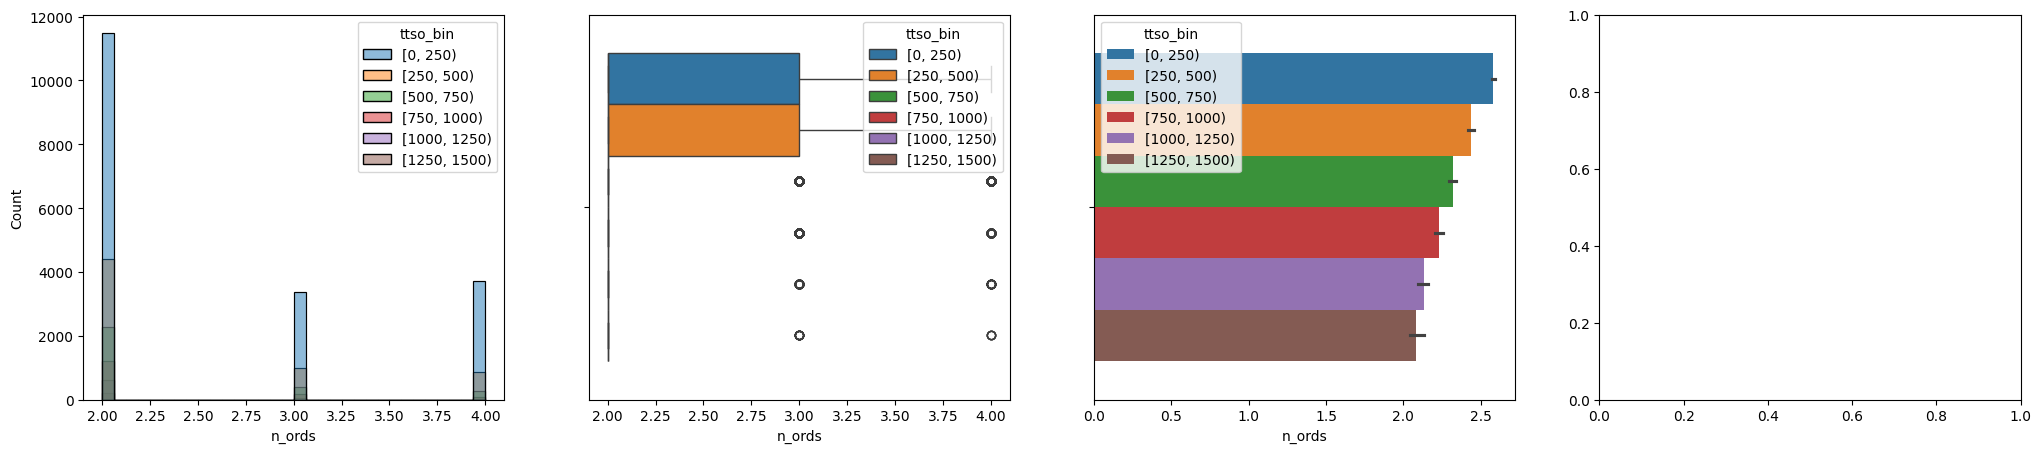

In [107]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[2]
sns.histplot(data=user_value, x='n_ords', hue = 'ttso_bin', ax=ax[0])
sns.boxplot(data=user_value, x='n_ords', hue = 'ttso_bin', ax=ax[1])
sns.barplot(data=user_value, x='n_ords', hue = 'ttso_bin', ax=ax[2])
plt.show()

In [108]:
b[3]

'first_order_rev'

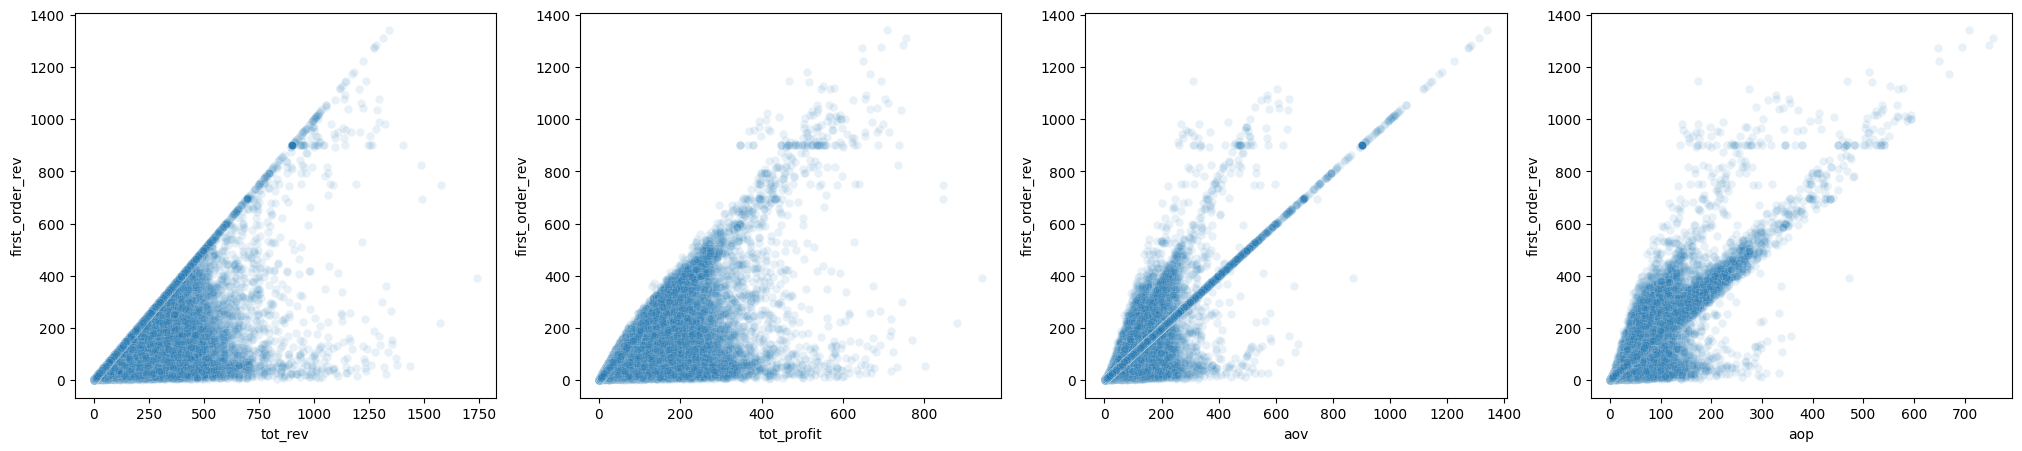

In [110]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[3]
for i in range(len(ltv)):
    sns.scatterplot(data=user_value, x=ltv[i], y = v, ax=ax[i], alpha=0.1)
plt.show()

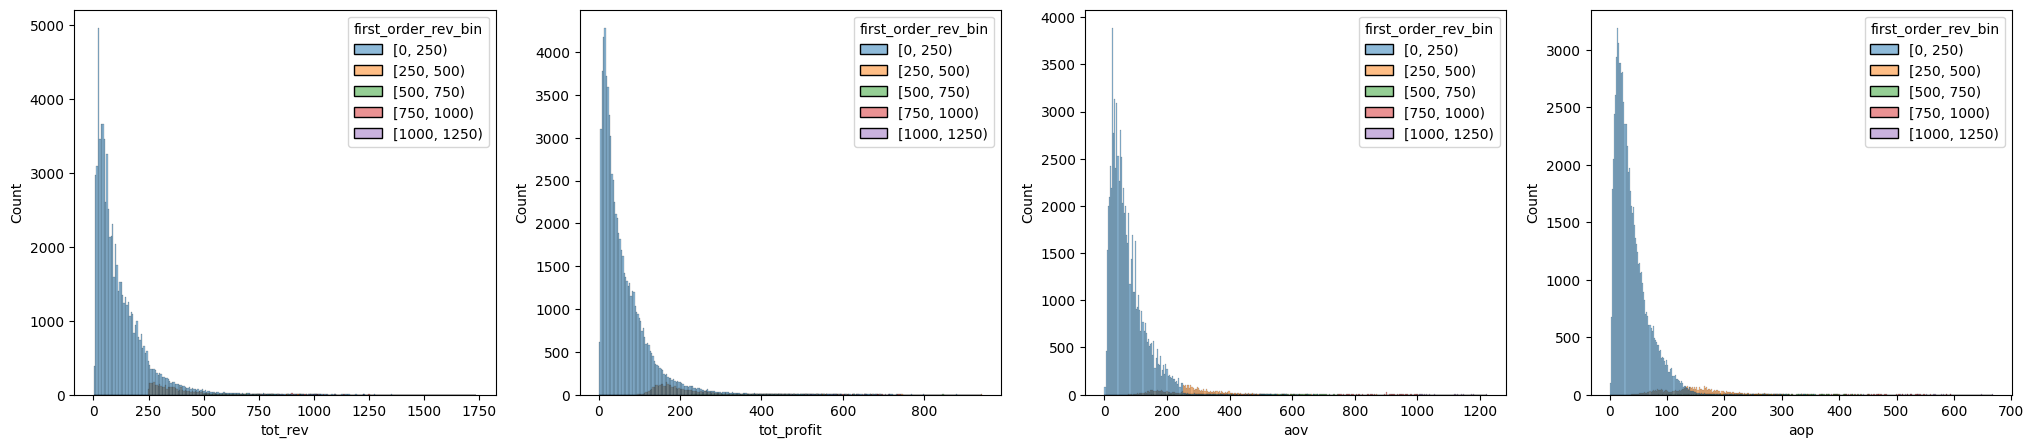

In [114]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[4]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

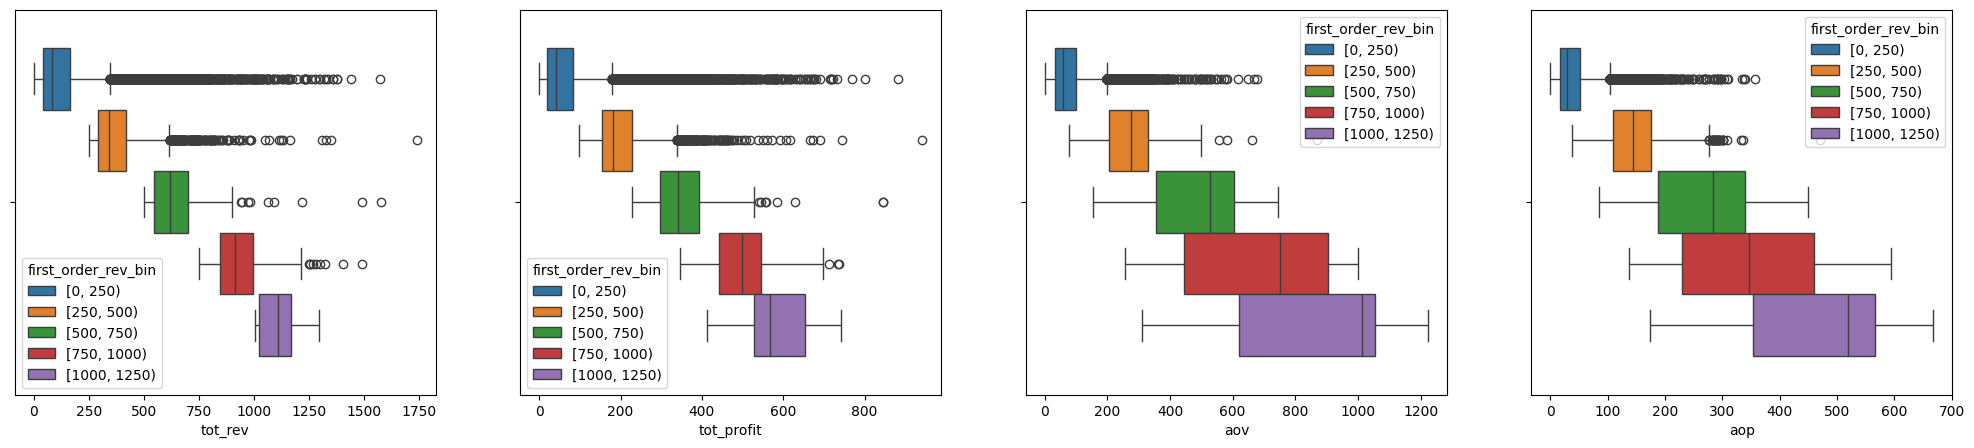

In [115]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[4]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

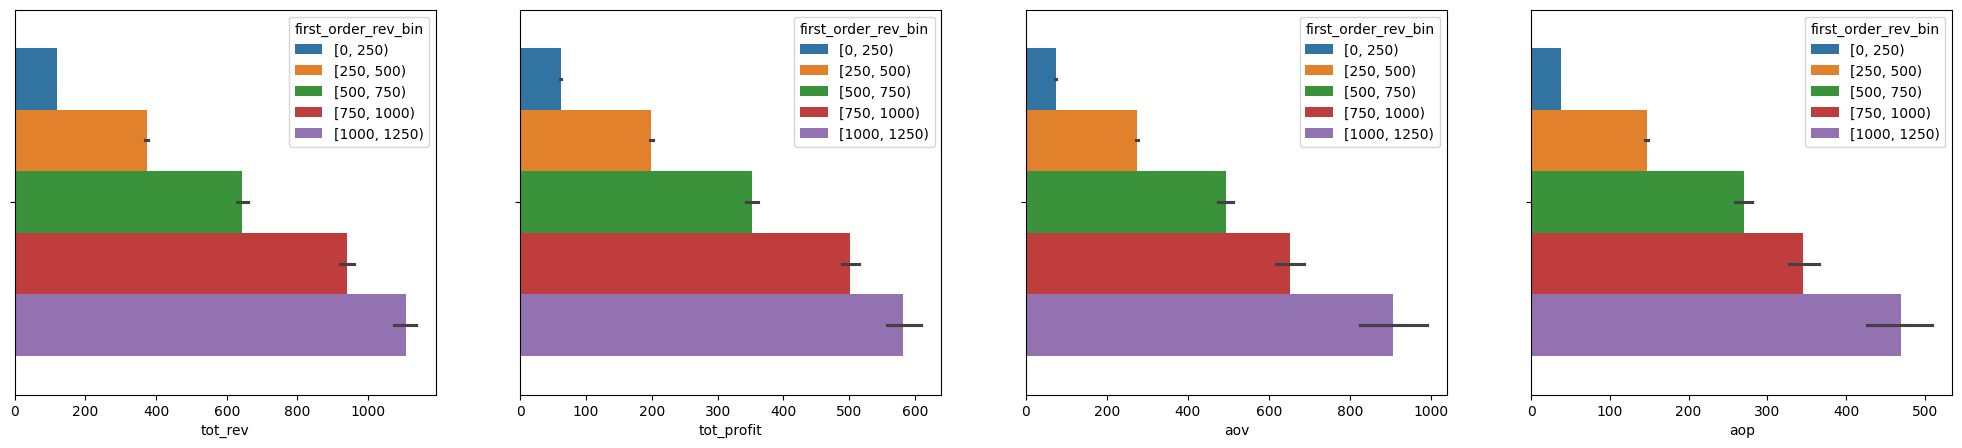

In [116]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[4]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

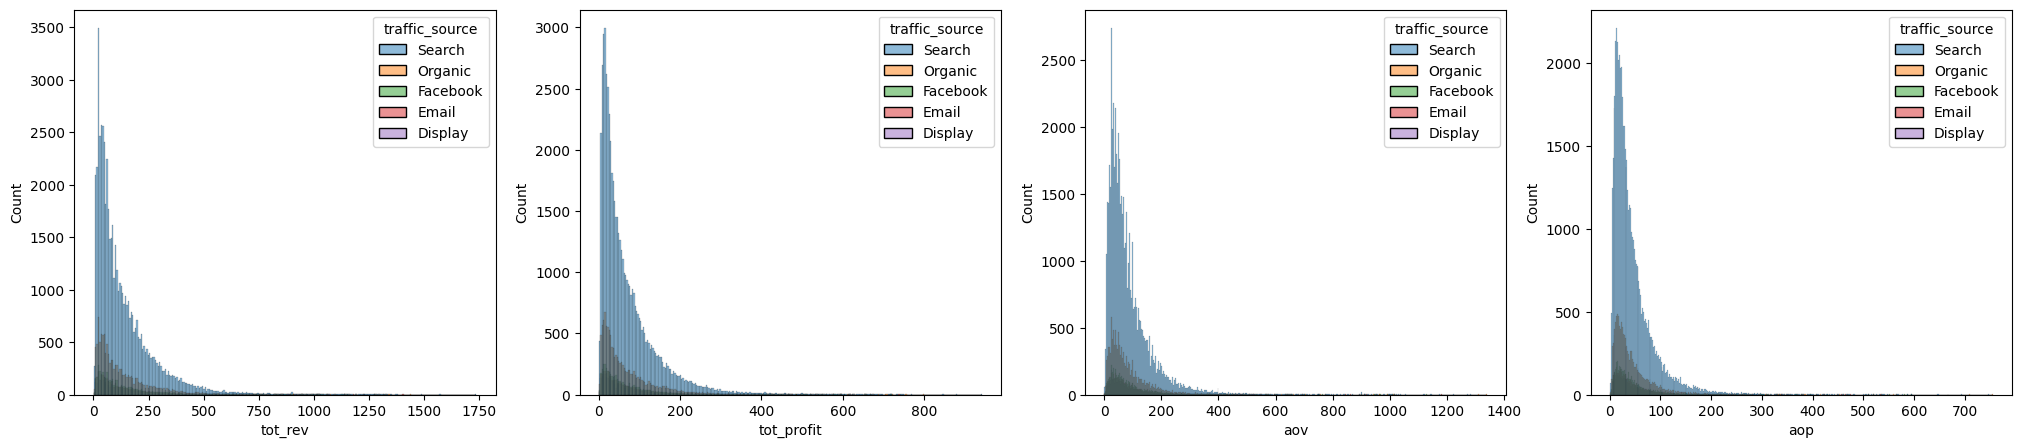

In [117]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[5]
for i in range(len(ltv)):
    sns.histplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

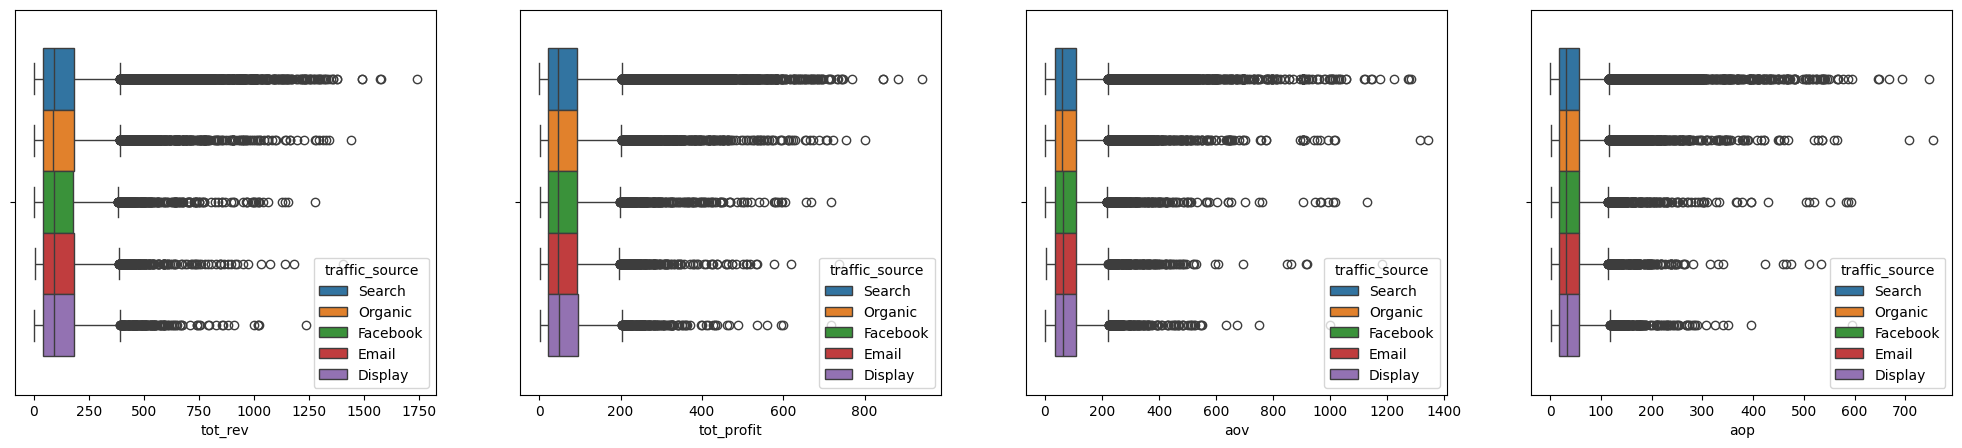

In [118]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[5]
for i in range(len(ltv)):
    sns.boxplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

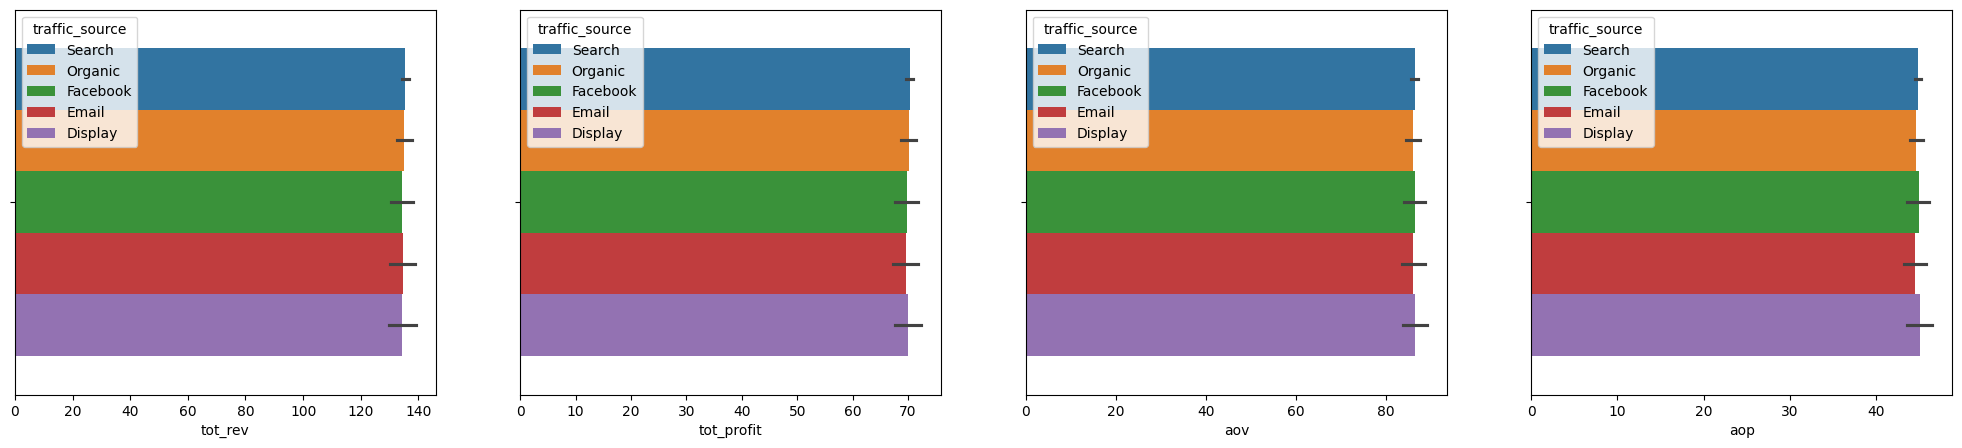

In [119]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[5]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

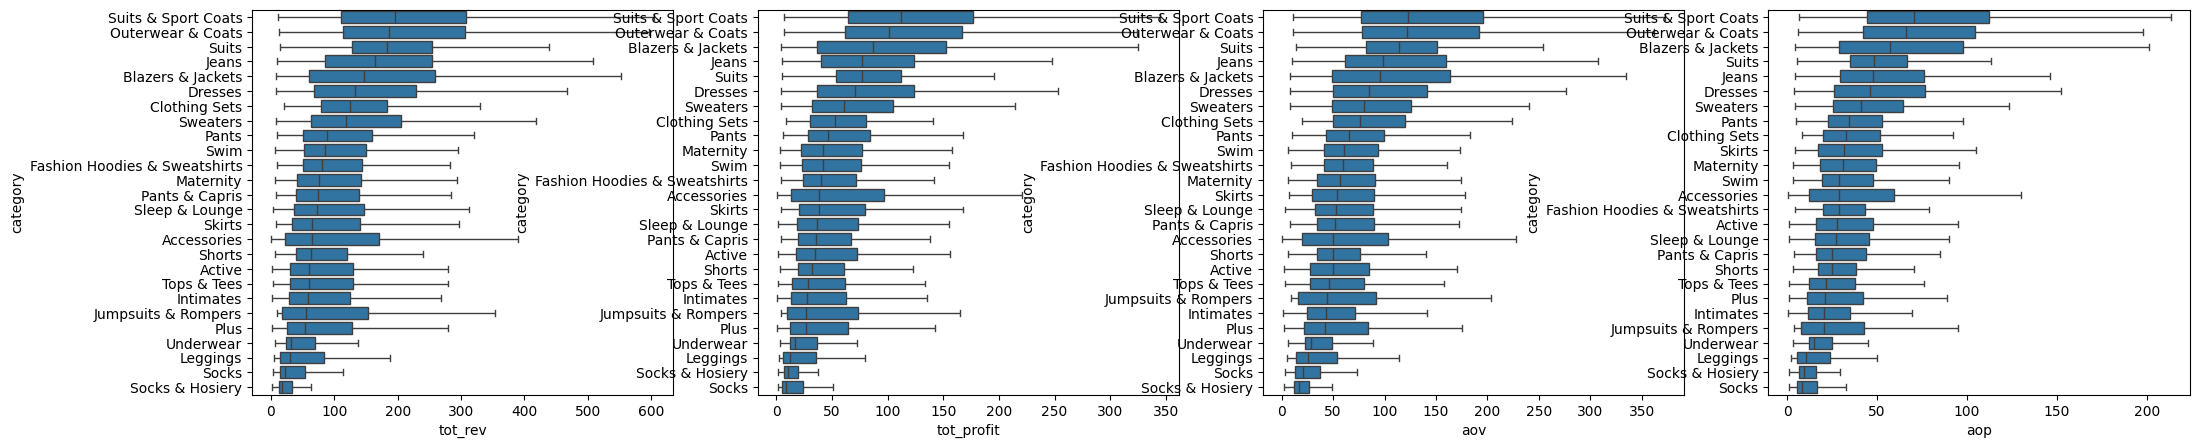

In [145]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[6]
for i in range(len(ltv)):
    v_order = user_value.groupby(v)[ltv[i]].median().sort_values(ascending=False).index
    sns.boxplot(data=user_value, x=ltv[i], y = v, ax=ax[i], order=v_order, showfliers=False)
plt.show()

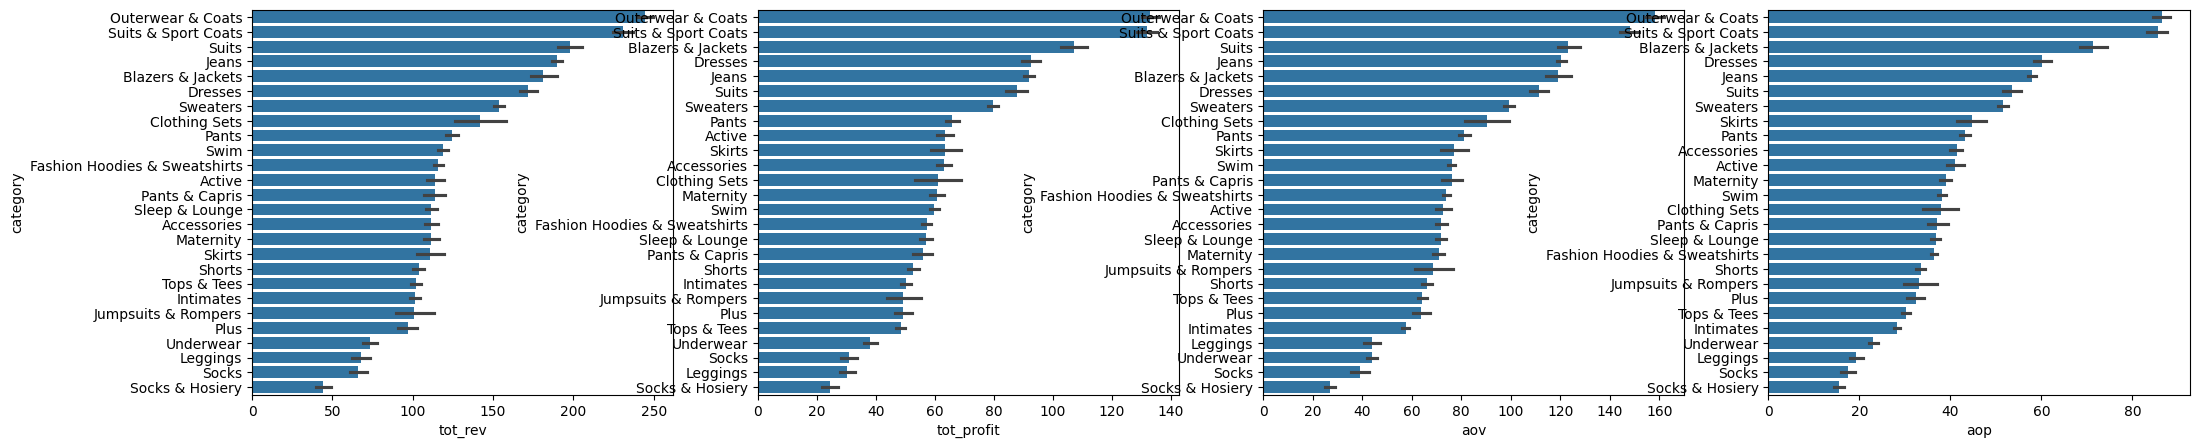

In [147]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[6]
for i in range(len(ltv)):
    v_order = user_value.groupby(v)[ltv[i]].mean().sort_values(ascending=False).index
    sns.barplot(data=user_value, x=ltv[i], y = v, ax=ax[i], order=v_order)
plt.show()

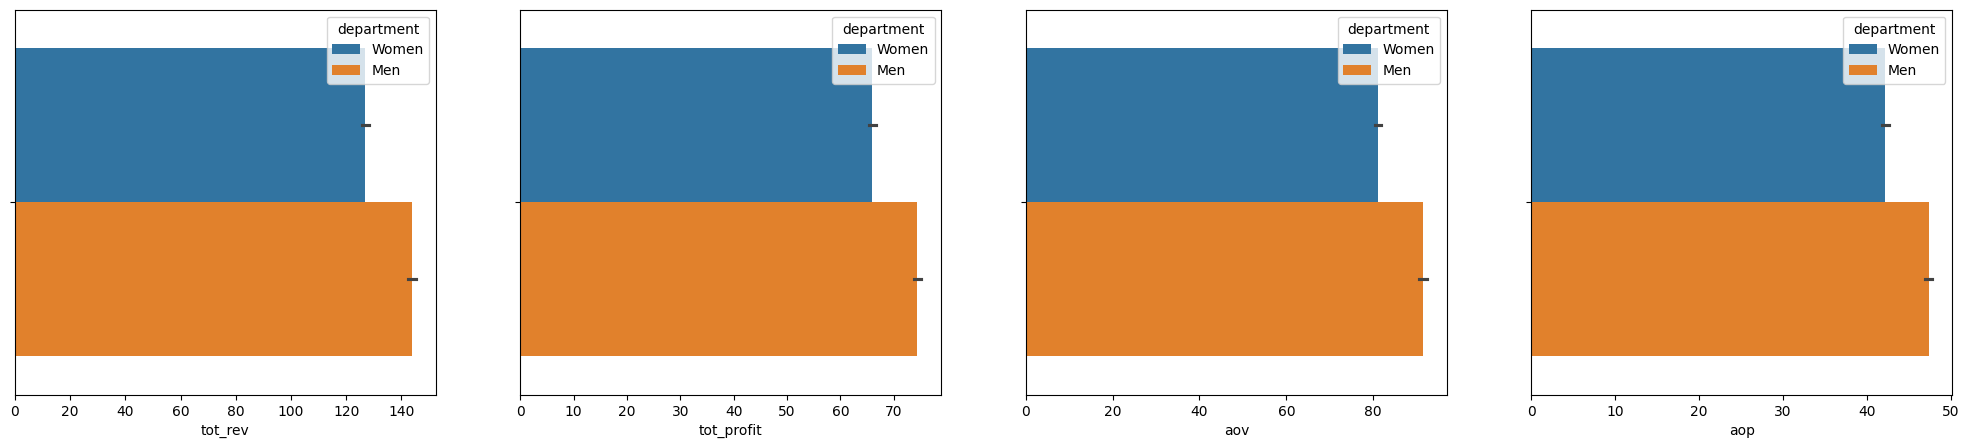

In [124]:
fig, ax = plt.subplots(1, len(ltv), figsize = (25, 5))
v = b[7]
for i in range(len(ltv)):
    sns.barplot(data=user_value, x=ltv[i], hue = v, ax=ax[i])
plt.show()

### Where do post-purchase drop-offs occur (e.g. returns, low engagement), and how do these vary by segment?